In [1]:
import sys
from pathlib import Path
repo_root = Path().resolve().parent  
sys.path.append(str(repo_root))

In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly import express as px
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, learning_curve, LearningCurveDisplay, RandomizedSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge, ElasticNet,  ElasticNetCV, RidgeCV, LassoCV, SGDRegressor, LassoLarsCV, LinearRegression
import matplotlib.pyplot as plt
from src.data.Segment_Slicer import SegmentSlicer 
SegmentSlicer = SegmentSlicer()
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import pickle

# 1. Load Data

In [3]:
df= pd.read_parquet(repo_root / 'data' / 'processed' / 'reunion_segments_cleaned.parquet')

In [4]:
print(f"📊 Dataset: {len(df)} segments")
print(f"   Running: {(df['activity_type']=='Run').sum()}")
print(f"   Cycling: {(df['activity_type']=='Ride').sum()}")

📊 Dataset: 6341 segments
   Running: 3481
   Cycling: 2860


In [5]:
mask_outlier = (df['best_time'] < df['average_top_10_time'] / 2)
df.loc[mask_outlier, 'best_time'] = df.loc[mask_outlier, 'average_top_10_time'].astype(int)
print(f"🚫 Removed {(mask_outlier).sum()} outliers where best_time < average_top_10_time / 2")

🚫 Removed 217 outliers where best_time < average_top_10_time / 2


In [6]:
Train, Test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['activity_type'])
Train, Val = train_test_split(Train, test_size=0.25, random_state=42, stratify=Train['activity_type'])
print(f"Train: {len(Train)}, Val: {len(Val)}, Test: {len(Test)}")

Train: 3804, Val: 1268, Test: 1269


In [7]:
# Séparer Ride et Run
Train_ride = Train[Train['activity_type'] == 'Ride'].copy()
Train_run = Train[Train['activity_type'] == 'Run'].copy()

Val_ride = Val[Val['activity_type'] == 'Ride'].copy()
Val_run = Val[Val['activity_type'] == 'Run'].copy()

Test_ride = Test[Test['activity_type'] == 'Ride'].copy()
Test_run = Test[Test['activity_type'] == 'Run'].copy()

In [8]:
Train_Val_Test_ride = pd.concat([Train_ride, Val_ride, Test_ride], ignore_index=True)
Train_Val_Test_run = pd.concat([Train_run, Val_run, Test_run], ignore_index=True)

# 2. High Confidence T1 segments

In [9]:
T1_active_learning_ride = pd.read_csv(repo_root / 'data' / 'processed' / 'T1_active_learning_threshold_7_ride.csv')
T1_road_naming_ride = pd.read_csv(repo_root / 'data' / 'processed' / 'T1_road_naming_ride.csv')
segments_manually_labeled = pd.read_csv(repo_root / 'data' / 'processed' / 'segments_manually_labeled.csv')
T1_segments_manually_labeled_ride = segments_manually_labeled[(segments_manually_labeled['technicality'] == 1) & (segments_manually_labeled['segment_id'].isin(df[df['activity_type'] == 'Ride']['segment_id']))].copy()
not_T1_segments_manually_labeled_ride = segments_manually_labeled[(segments_manually_labeled['technicality'] != 1) & (segments_manually_labeled['segment_id'].isin(df[df['activity_type'] == 'Ride']['segment_id']))].copy()
segments_manually_deleted = pd.read_csv(repo_root / 'data' / 'processed' / 'segments_manually_deleted.csv')

T1_ride = pd.concat([T1_active_learning_ride, T1_road_naming_ride, T1_segments_manually_labeled_ride]).drop_duplicates().reset_index(drop=True)
T1_ride = T1_ride.drop(T1_ride[T1_ride['segment_id'].isin(not_T1_segments_manually_labeled_ride['segment_id'])].index).reset_index(drop=True)
T1_ride = T1_ride.drop(T1_ride[T1_ride['segment_id'].isin(segments_manually_deleted['segment_id'])].index).reset_index(drop=True)

print(f"Total T1 Ride segments labeled: {len(T1_ride)}")

Total T1 Ride segments labeled: 617


In [10]:
X_train_ride_T1 = Train_ride.merge(T1_ride[['segment_id', 'technicality']], on='segment_id', how='inner')
y_train_ride_T1 = X_train_ride_T1['best_time'].fillna(0).astype(int)

X_val_ride_T1 = Val_ride.merge(T1_ride[['segment_id', 'technicality']], on='segment_id', how='inner')
y_val_ride_T1 = X_val_ride_T1['best_time'].fillna(0).astype(int)

X_test_ride_T1 = Test_ride.merge(T1_ride[['segment_id', 'technicality']], on='segment_id', how='inner')
y_test_ride_T1 = X_test_ride_T1['best_time'].fillna(0).astype(int)

## Baseline features

### Baseline Model

In [11]:
X_train_ride_T1_bm = X_train_ride_T1.loc[:, ['distance', 'elevation_gain', 'elevation_low', 'elevation_high']].copy()
X_val_ride_T1_bm = X_val_ride_T1.loc[:, ['distance', 'elevation_gain', 'elevation_low', 'elevation_high']].copy()
y_train_ride_T1_bm = y_train_ride_T1.copy()
y_val_ride_T1_bm = y_val_ride_T1.copy()


In [12]:
pipeline_bm = Pipeline([
    ('model', LinearRegression())
])

In [13]:
def plotting_MAE_bins(y_train, y_train_pred, y_val, y_val_pred):
    # Définir les bins de durée
    bins = [0, 60, 300, 900, 3600, np.inf]
    labels = ['<1min', '1-5min', '5-15min', '15-60min', '>60min']

    # Créer DataFrames temporaires avec bins
    train_df = pd.DataFrame({
        'actual': y_train,
        'pred': y_train_pred
    })
    train_df['bin'] = pd.cut(train_df['actual'], bins=bins, labels=labels)

    val_df = pd.DataFrame({
        'actual': y_val,
        'pred': y_val_pred
    })
    val_df['bin'] = pd.cut(val_df['actual'], bins=bins, labels=labels)

    # Calculer les métriques par bin
    results = []
    for bin_label in labels:
        train_mask = train_df['bin'] == bin_label
        val_mask = val_df['bin'] == bin_label
        
        if train_mask.sum() > 0 and val_mask.sum() > 0:
            train_mae = np.mean(np.abs(train_df.loc[train_mask, 'actual'] - train_df.loc[train_mask, 'pred']))
            val_mae = np.mean(np.abs(val_df.loc[val_mask, 'actual'] - val_df.loc[val_mask, 'pred']))
            
            train_n = train_mask.sum()
            val_n = val_mask.sum()
            
            results.append({
                'Durée': bin_label,
                'Train N': train_n,
                'Train MAE': f"{train_mae:.0f}s",
                'Val N': val_n,
                'Val MAE': f"{val_mae:.0f}s"
            })

    # Créer et afficher le tableau
    results_df = pd.DataFrame(results)

    print("\n" + "="*70)
    print("PERFORMANCE PAR BIN DE DURÉE")
    print("="*70)
    print(results_df.to_string(index=False))
    print("="*70)

    # Métriques globales
    print(f"\nGLOBAL - Train RMSE: {root_mean_squared_error(y_train, y_train_pred):.2f}")
    print(f"GLOBAL - Train MAE: {mean_absolute_error(y_train, y_train_pred):.1f}s")
    print(f"GLOBAL - Validation RMSE: {root_mean_squared_error(y_val, y_val_pred):.2f}")
    print(f"GLOBAL - Validation MAE: {mean_absolute_error(y_val, y_val_pred):.1f}s")
    return None

In [14]:
def plotting_pred_vs_actual_LC(pipeline, X_train, y_train, X_val, y_val, Train_df, Val_df):
    
    pipeline.fit(X_train.select_dtypes(include=[np.number]), y_train)
    y_val_pred = pipeline.predict(X_val.select_dtypes(include=[np.number]))
    y_train_pred = pipeline.predict(X_train.select_dtypes(include=[np.number]))

    plotting_MAE_bins(y_train, y_train_pred, y_val, y_val_pred)

    train_size_abs, train_scores, test_scores = learning_curve(
        pipeline, X_train.select_dtypes(include=[np.number]), y_train,
        cv=5, scoring='neg_root_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    fig = make_subplots(rows=1, cols=3, subplot_titles=("Learning Curve", "Train Prediction vs Actual", "Validation Prediction vs Actual"))
    
    # Plot learning curve
    train_sizes = np.linspace(0.1, 1.0, 10) * len(X_train)
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    fig.add_trace(
        go.Scatter(
            x=train_sizes,
            y=train_scores_mean,
            mode='lines+markers',
            name='Train Score',
            line=dict(color='blue'),
            hovertemplate='Size: %{x:.0f}<br>MAE: %{y:.0f}s<extra></extra>'
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=train_sizes,
            y=test_scores_mean,
            mode='lines+markers',
            name='Val Score',
            line=dict(color='red'),
            hovertemplate='Size: %{x:.0f}<br>MAE: %{y:.0f}s<extra></extra>'
        ),
        row=1, col=1
    )
    fig.update_xaxes(title_text="Training Examples", row=1, col=1)
    fig.update_yaxes(title_text="MAE", row=1, col=1, range=[min(train_scores_mean)*0.9, min(test_scores_mean)*1.3])
    
    ###################### PLOT Train Prediction vs Actual ######################
    # IMPORTANT: Reset index de Train_df pour aligner avec X_train
    Train_df_filtered = Train_df.loc[y_train.index]
    
    Train_df_reset = Train_df_filtered.reset_index(drop=True)
    
    # Créer DataFrame avec les prédictions et les segment_ids alignés par position
    X_train_with_info = pd.DataFrame({
        'segment_id': Train_df_reset['segment_id'].values,
        'actual': y_train.values if isinstance(y_train, pd.Series) else y_train,
        'predicted': y_train_pred
    })
    
    # Plot prediction vs actual values
    fig.add_trace(
        go.Scatter(
            x=X_train_with_info['actual'],
            y=X_train_with_info['predicted'],
            mode='markers',  
            marker=dict(symbol="x-thin", size=5, line=dict(width=1, color='red')),
            name='Train Predictions',
            text=X_train_with_info['segment_id'],
            customdata=X_train_with_info['segment_id'],
            hovertemplate="<b>Segment ID:</b> %{text}<br>" +
                        "<b>Actual:</b> %{x:.0f}s<br>" +
                        "<b>Predicted:</b> %{y:.0f}s<extra></extra>"
        ),
        row=1, col=2
    )
    # Add a line for perfect predictions
    fig.add_trace(
        go.Scatter(
            x=[10, 10000],
            y=[10, 10000],
            mode='lines',
            line=dict(dash='dash', color='black'),
            showlegend=False
        ),
        row=1, col=2
    )
    fig.update_xaxes(title_text="Actual", row=1, col=2, type='log', range=[1,4])
    fig.update_yaxes(title_text="Predicted", row=1, col=2, type='log', range=[1,4])
    
    ###################### PLOT Validation Prediction vs Actual ######################
    # IMPORTANT: Reset index de Val_df pour aligner avec X_val
    Val_df_filtered = Val_df.loc[y_val.index]
    
    Val_df_reset = Val_df_filtered.reset_index(drop=True)
    
    # Créer DataFrame avec les prédictions et les segment_ids alignés par position
    X_val_with_info = pd.DataFrame({
        'segment_id': Val_df_reset['segment_id'].values,
        'actual': y_val.values if isinstance(y_val, pd.Series) else y_val,
        'predicted': y_val_pred
    })
    
    # Plot prediction vs actual values
    fig.add_trace(
        go.Scatter(
            x=X_val_with_info['actual'],
            y=X_val_with_info['predicted'],
            mode='markers',  
            marker=dict(symbol="x-thin", size=5, line=dict(width=1, color='green')),
            name='Validation Predictions',
            text=X_val_with_info['segment_id'],
            customdata=X_val_with_info['segment_id'],
            hovertemplate="<b>Segment ID:</b> %{text}<br>" +
                        "<b>Actual:</b> %{x:.0f}s<br>" +
                        "<b>Predicted:</b> %{y:.0f}s<extra></extra>"
        ),
        row=1, col=3
    )
    # Add a line for perfect predictions
    fig.add_trace(
        go.Scatter(
            x=[10, 10000],
            y=[10, 10000],
            mode='lines',
            line=dict(dash='dash', color='black'),
            showlegend=False
        ),
        row=1, col=3
    )
    fig.update_xaxes(title_text="Actual", row=1, col=3, type='log', range=[1,4])
    fig.update_yaxes(title_text="Predicted", row=1, col=3, type='log', range=[1,4])
    
    # Update layout
    fig.update_layout(
        height=500,
        width=1400,
        title_text=f"Model Evaluation",
        hovermode='closest'
    )
    fig.show()
    return None

In [15]:
plotting_pred_vs_actual_LC(pipeline_bm, X_train_ride_T1_bm, y_train_ride_T1_bm, X_val_ride_T1_bm, y_val_ride_T1_bm, X_train_ride_T1, X_val_ride_T1)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min       69       26s     23     28s
  1-5min      182       43s     68     38s
 5-15min       79       84s     28     91s
15-60min       29      191s     11    306s
  >60min        5      239s      2     91s

GLOBAL - Train RMSE: 103.52
GLOBAL - Train MAE: 63.3s
GLOBAL - Validation RMSE: 146.16
GLOBAL - Validation MAE: 70.6s


## Advanced features

In [16]:
def extract_features_from_sections(sections, segment_id=None):
    """
    Extrait des features simples à partir des sections d'un segment.
    
    Input: sections (list of dict) - output de segment_slicer.cut_segment()
    Output: dict of features
    """
    
    if not sections or len(sections) == 0:
        return None
    
    # ========== Features Basiques ==========
    total_distance = sum(s['distance'] for s in sections) / 1000  # en km
    total_elevation_gain = sum(s['elevation_gain'] for s in sections)
    total_elevation_loss = sum(s['elevation_loss'] for s in sections)
    
    # Grades
    all_grades = [s['grade'] for s in sections]
    avg_grade = np.mean(all_grades)
    max_grade = max(s['max_grade'] for s in sections)
    min_grade = min(s['min_grade'] for s in sections)
    
    # ========== Features d'Ordre (Capture la Séquence) ==========
    
    # 1. Distribution des montées (early vs late)
    early_third_distance = total_distance * 1000 * 0.33
    late_third_distance = total_distance * 1000 * 0.67
    
    early_climb_gain = sum(s['elevation_gain'] for s in sections 
                           if s['start_distance'] < early_third_distance)
    late_climb_gain = sum(s['elevation_gain'] for s in sections 
                          if s['start_distance'] > late_third_distance)
    
    early_climb_ratio = early_climb_gain / (total_elevation_gain + 1e-6)
    late_climb_ratio = late_climb_gain / (total_elevation_gain + 1e-6)
    
    # 2. Grade pondéré par position (effet fatigue)
    weighted_grade = 0
    for i, s in enumerate(sections):
        position_weight = 1 + (i / len(sections)) * 0.5  # 1.0 à 1.5x
        weighted_grade += s['grade'] * position_weight * s['distance']
    weighted_grade /= (total_distance * 1000)
    
    # 3. Position de la section la plus dure
    hardest_idx = np.argmax([s['grade'] * s['distance'] for s in sections])
    hardest_section_position = hardest_idx / len(sections)  # 0 à 1
    
    # 4. Variabilité du terrain
    grade_variance = np.mean([s['grade_variance'] for s in sections])
    
    # 5. Stats par tiers du segment
    first_third = [s for s in sections if s['start_distance'] < early_third_distance]
    middle_third = [s for s in sections 
                    if early_third_distance <= s['start_distance'] <= late_third_distance]
    last_third = [s for s in sections if s['start_distance'] > late_third_distance]
    
    first_third_avg_grade = np.mean([s['grade'] for s in first_third]) if first_third else 0
    middle_third_avg_grade = np.mean([s['grade'] for s in middle_third]) if middle_third else 0
    last_third_avg_grade = np.mean([s['grade'] for s in last_third]) if last_third else 0
    
    # 6. Compter les types de sections
    n_climbs = sum(1 for s in sections if s['type'] in ['climb', 'uphill'])
    n_descents = sum(1 for s in sections if s['type'] in ['descent', 'downhill'])
    n_flats = sum(1 for s in sections if s['type'] == 'flat')

    # 7. Features lié au data leakage
    best_time = df.loc[df['segment_id'] == segment_id, 'best_time'].iloc[0]
    avg_top_10_time = df.loc[df['segment_id'] == segment_id, 'average_top_10_time'].iloc[0]
    total_effort_count = df.loc[df['segment_id'] == segment_id, 'total_effort_count'].iloc[0]
    inv_total_effort_count = 1 / (total_effort_count + 1e-6)    
    
    # ========== Assembler le dictionnaire de features ==========
    features = {
        # Basiques
        'total_distance_km': total_distance,
        'total_elevation_gain': total_elevation_gain,
        'total_elevation_loss': total_elevation_loss,
        'avg_grade': avg_grade,
        'max_grade': max_grade,
        'min_grade': min_grade,
        'grade_variance': grade_variance,
        
        # Ordre et fatigue
        'early_climb_ratio': early_climb_ratio,
        'late_climb_ratio': late_climb_ratio,
        'weighted_grade': weighted_grade,
        'hardest_section_position': hardest_section_position,
        
        # Tiers
        'first_third_avg_grade': first_third_avg_grade,
        'middle_third_avg_grade': middle_third_avg_grade,
        'last_third_avg_grade': last_third_avg_grade,
        
        # Comptages
        'n_sections': len(sections),
        'n_climbs': n_climbs,
        'n_descents': n_descents,
        'n_flats': n_flats,

        # Data leakage
        #'best_time': best_time,
        #'avg_top_10_time': avg_top_10_time,
        #'total_effort_count': total_effort_count,
        #'inv_total_effort_count': inv_total_effort_count
    }
    
    return features

In [17]:
def extract_features_for_dataframe(df, sections_dict):
    """
    Extrait les features pour tous les segments d'une DataFrame.
    
    Input:
        - df: DataFrame avec les segments (doit avoir une colonne 'id')
        - sections_dict: dict {segment_id: sections} où sections = output de cut_segment
    
    Output:
        - features_df: DataFrame avec les features
        - valid_indices: indices des segments traités avec succès
    """
    
    features_list = []
    valid_indices = []
    
    for idx, row in df.iterrows():
        segment_id = row['segment_id']
        
        # Vérifier si on a les sections pour ce segment
        if segment_id not in sections_dict:
            print(f"Warning: No sections found for segment {segment_id}")
            continue
        
        sections = sections_dict[segment_id]
        
        # Extraire les features
        features = extract_features_from_sections(sections, segment_id=segment_id)
        
        if features is not None:
            features_list.append(features)
            valid_indices.append(idx)
        else:
            print(f"Warning: Could not extract features for segment {segment_id}")
    
    # Créer la DataFrame de features
    features_df = pd.DataFrame(features_list, index=valid_indices)
    
    print(f"✓ Extracted features for {len(features_df)} / {len(df)} segments")
    
    return features_df, valid_indices

In [18]:
sections_dict = {}
for idx, row in Train_Val_Test_ride.iterrows():
    segment_id = row['segment_id']
    # Charger altitude_profile, distance_profile, coordinates
    sections = SegmentSlicer.cut_segment(row['altitude_profile'], row['distance_profile'], row['coordinates'])
    sections_dict[segment_id] = sections

In [19]:
first_key = list(sections_dict.keys())[0]
for section in sections_dict[first_key]:
    if isinstance(section, dict):
        for key, value in section.items():
            print(f"{key}: {value}")
    else:
        print(section)
    print("\n")


type: climb
category: Cat 4
start_distance: 0.0
end_distance: 1381.199999999997
distance: 1381.199999999997
start_altitude: 139.6
end_altitude: 230.6
elevation_gain: 90.6
elevation_loss: 0
elevation_change: 90.6
grade: 6.559513466550839
max_grade: 11.819407802874615
min_grade: 3.619408134696357
grade_variance: 2.848174484890411
sharp_turns: 0
start_idx: 0
end_idx: 224




### Model 1 - Ridge

In [20]:
X_train_ride_1, valid_idx_train_1 = extract_features_for_dataframe(X_train_ride_T1, sections_dict)
y_train_ride_1 = y_train_ride_T1.loc[valid_idx_train_1]

X_val_ride_1, valid_idx_val_1 = extract_features_for_dataframe(X_val_ride_T1, sections_dict)
y_val_ride_1 = y_val_ride_T1.loc[valid_idx_val_1]

✓ Extracted features for 364 / 364 segments
✓ Extracted features for 132 / 132 segments


In [21]:
pipeline1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(
        alpha=50
    ))
])

In [22]:
pipeline1.fit(X_train_ride_1.select_dtypes(include=[np.number]), y_train_ride_1)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,50
,fit_intercept,True
,copy_X,True
,max_iter,None


In [23]:
plotting_pred_vs_actual_LC(pipeline1, X_train_ride_1, y_train_ride_1, X_val_ride_1, y_val_ride_1, X_train_ride_T1, X_val_ride_T1)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min       69       42s     23     36s
  1-5min      182       46s     68     49s
 5-15min       79       83s     28     84s
15-60min       29      246s     11    346s
  >60min        5      516s      2    112s

GLOBAL - Train RMSE: 137.34
GLOBAL - Train MAE: 75.6s
GLOBAL - Validation RMSE: 157.92
GLOBAL - Validation MAE: 79.9s


In [24]:
## feature importance
importances = pipeline1.named_steps['model'].coef_
feature_names = X_train_ride_1.select_dtypes(include=[np.number]).columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print(feature_importance_df)

                     feature  importance
0          total_distance_km  397.175684
1       total_elevation_gain  210.966990
17                   n_flats  107.721852
2       total_elevation_loss   39.933686
4                  max_grade   37.852012
14                n_sections   34.360599
5                  min_grade   22.368490
6             grade_variance    6.455490
10  hardest_section_position    2.474181
11     first_third_avg_grade    2.157394
7          early_climb_ratio   -0.651485
8           late_climb_ratio   -4.464451
13      last_third_avg_grade   -8.903726
15                  n_climbs   -9.664720
9             weighted_grade  -10.319195
3                  avg_grade  -11.919210
12    middle_third_avg_grade  -15.344855
16                n_descents  -34.285287


### Model 2 - Elastic Net CV

In [25]:
X_train_ride_2 = X_train_ride_1.copy()  
y_train_ride_2 = y_train_ride_1.copy()

X_val_ride_2 = X_val_ride_1.copy()  
y_val_ride_2 = y_val_ride_1.copy()

In [26]:
pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(cv=2, random_state=42))
])


In [27]:
pipeline2.fit(X_train_ride_2.select_dtypes(include=[np.number]), y_train_ride_2)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,l1_ratio,0.5
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'


In [28]:
plotting_pred_vs_actual_LC(pipeline2, X_train_ride_2, y_train_ride_2, X_val_ride_2, y_val_ride_2, X_train_ride_T1, X_val_ride_T1)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min       69       85s     23     90s
  1-5min      182       67s     68     73s
 5-15min       79      113s     28    126s
15-60min       29      417s     11    511s
  >60min        5     1136s      2    417s

GLOBAL - Train RMSE: 238.84
GLOBAL - Train MAE: 123.1s
GLOBAL - Validation RMSE: 215.07
GLOBAL - Validation MAE: 128.8s


### Model 3 - Ridge CV

In [29]:
X_train_ride_3 = X_train_ride_1.copy()  
y_train_ride_3 = y_train_ride_1.copy()

X_val_ride_3 = X_val_ride_1.copy()  
y_val_ride_3 = y_val_ride_1.copy()

In [30]:
pipeline3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=10))
])
pipeline3.fit(X_train_ride_3.select_dtypes(include=[np.number]), y_train_ride_3)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alphas,"(0.1, ...)"
,fit_intercept,True
,scoring,None
,cv,10


In [31]:
plotting_pred_vs_actual_LC(pipeline3, X_train_ride_3, y_train_ride_3, X_val_ride_3, y_val_ride_3, X_train_ride_T1, X_val_ride_T1)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min       69       32s     23     30s
  1-5min      182       41s     68     45s
 5-15min       79       82s     28     75s
15-60min       29      182s     11    321s
  >60min        5      286s      2     90s

GLOBAL - Train RMSE: 104.35
GLOBAL - Train MAE: 63.1s
GLOBAL - Validation RMSE: 144.96
GLOBAL - Validation MAE: 72.6s


### Model 4 - Lasso CV

In [32]:
X_train_ride_4 = X_train_ride_1.copy()  
y_train_ride_4 = y_train_ride_1.copy()

X_val_ride_4 = X_val_ride_1.copy()  
y_val_ride_4 = y_val_ride_1.copy()

In [33]:
pipeline4 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(cv=10, random_state=42))
])
pipeline4.fit(X_train_ride_4.select_dtypes(include=[np.number]), y_train_ride_4)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True


In [34]:
plotting_pred_vs_actual_LC(pipeline4, X_train_ride_4, y_train_ride_4, X_val_ride_4, y_val_ride_4, X_train_ride_T1, X_val_ride_T1)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min       69       13s     23     13s
  1-5min      182       39s     68     34s
 5-15min       79       80s     28     68s
15-60min       29      203s     11    306s
  >60min        5      296s      2    156s

GLOBAL - Train RMSE: 115.69
GLOBAL - Train MAE: 59.6s
GLOBAL - Validation RMSE: 145.67
GLOBAL - Validation MAE: 62.2s


In [35]:
## feature importance
importances = pipeline4.named_steps['model'].coef_
feature_names = X_train_ride_4.select_dtypes(include=[np.number]).columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print(feature_importance_df)

                     feature  importance
0          total_distance_km  561.337493
1       total_elevation_gain  195.379660
2       total_elevation_loss    0.000000
3                  avg_grade   -0.000000
4                  max_grade    0.000000
5                  min_grade    0.000000
6             grade_variance    0.000000
7          early_climb_ratio    0.000000
8           late_climb_ratio   -0.000000
9             weighted_grade   -0.000000
10  hardest_section_position   -0.000000
11     first_third_avg_grade    0.000000
12    middle_third_avg_grade    0.000000
13      last_third_avg_grade   -0.000000
14                n_sections   -0.000000
16                n_descents   -0.000000
17                   n_flats    0.000000
15                  n_climbs   -7.452305


## More advanced features

In [36]:
def extract_features_from_sections_2(sections, segment_id=None, df=None):
    """
    Extrait des features simples à partir des sections d'un segment.
    
    Input: sections (list of dict) - output de segment_slicer.cut_segment()
    Output: dict of features
    """
    
    if not sections or len(sections) == 0:
        return None
    
    # ========== Features Basiques ==========
    total_distance = sum(s['distance'] for s in sections) / 1000  # en km
    total_elevation_gain = sum(s['elevation_gain'] for s in sections)
    total_elevation_loss = sum(s['elevation_loss'] for s in sections)
    
    # Grades
    all_grades = [s['grade'] for s in sections]
    avg_grade = np.mean(all_grades)
    max_grade = max(s['max_grade'] for s in sections)
    min_grade = min(s['min_grade'] for s in sections)
    
    # ========== Features d'Ordre (Capture la Séquence) ==========
    
    # 1. Distribution des montées (early vs late)
    early_third_distance = total_distance * 1000 * 0.33
    late_third_distance = total_distance * 1000 * 0.67
    
    early_climb_gain = sum(s['elevation_gain'] for s in sections 
                           if s['start_distance'] < early_third_distance)
    late_climb_gain = sum(s['elevation_gain'] for s in sections 
                          if s['start_distance'] > late_third_distance)
    
    early_climb_ratio = early_climb_gain / (total_elevation_gain + 1e-6)
    late_climb_ratio = late_climb_gain / (total_elevation_gain + 1e-6)
    
    # 2. Grade pondéré par position (effet fatigue)
    weighted_grade = 0
    for i, s in enumerate(sections):
        position_weight = 1 + (i / len(sections)) * 0.5  # 1.0 à 1.5x
        weighted_grade += s['grade'] * position_weight * s['distance']
    weighted_grade /= (total_distance * 1000)
    
    # 3. Position de la section la plus dure
    hardest_idx = np.argmax([s['grade'] * s['distance'] for s in sections])
    hardest_section_position = hardest_idx / len(sections)  # 0 à 1
    
    # 4. Variabilité du terrain
    grade_variance = np.mean([s['grade_variance'] for s in sections])
    
    # 5. Stats par tiers du segment
    first_third = [s for s in sections if s['start_distance'] < early_third_distance]
    middle_third = [s for s in sections 
                    if early_third_distance <= s['start_distance'] <= late_third_distance]
    last_third = [s for s in sections if s['start_distance'] > late_third_distance]
    
    first_third_avg_grade = np.mean([s['grade'] for s in first_third]) if first_third else 0
    middle_third_avg_grade = np.mean([s['grade'] for s in middle_third]) if middle_third else 0
    last_third_avg_grade = np.mean([s['grade'] for s in last_third]) if last_third else 0
    
    # 6. Compter les types de sections
    n_climbs = sum(1 for s in sections if s['type'] in ['climb', 'uphill'])
    n_descents = sum(1 for s in sections if s['type'] in ['descent', 'downhill'])
    n_flats = sum(1 for s in sections if s['type'] == 'flat')

    # 7. Features lié au data leakage
    if df is not None and segment_id is not None:
        segment_row = df[df['segment_id'] == segment_id].iloc[0]
        best_time = segment_row['best_time']
        avg_top_10_time = segment_row['average_top_10_time']
        total_effort_count = segment_row['total_effort_count']
        inv_total_effort_count = 1 / (total_effort_count + 1e-6)
    else:
        best_time = 0
        avg_top_10_time = 0
        total_effort_count = 0
        inv_total_effort_count = 0

    # 8. Distance par catégorie de montée
    cat_hc_distance = sum(s['distance'] for s in sections if s['category'] == 'Cat HC') / 1000  # en km
    cat_1_distance = sum(s['distance'] for s in sections if s['category'] == 'Cat 1') / 1000  # en km
    cat_2_distance = sum(s['distance'] for s in sections if s['category'] == 'Cat 2') / 1000  # en km
    cat_3_distance = sum(s['distance'] for s in sections if s['category'] == 'Cat 3') / 1000  # en km  
    cat_4_distance = sum(s['distance'] for s in sections if s['category'] == 'Cat 4') / 1000  # en km
    
    uphill_distance = sum(s['distance'] for s in sections if s['type'] == 'uphill') / 1000  # en km
    downhill_distance = sum(s['distance'] for s in sections if s['type'] == 'downhill') / 1000  # en km
    flat_distance = sum(s['distance'] for s in sections if s['type'] == 'flat') / 1000  # en km
        
    
    # ========== Assembler le dictionnaire de features ==========
    features = {
        # Basiques
        'total_distance_km': total_distance,
        'total_elevation_gain': total_elevation_gain,
        'total_elevation_loss': total_elevation_loss,
        'avg_grade': avg_grade,
        'max_grade': max_grade,
        'min_grade': min_grade,
        'grade_variance': grade_variance,
        
        # Ordre et fatigue
        'early_climb_ratio': early_climb_ratio,
        'late_climb_ratio': late_climb_ratio,
        'weighted_grade': weighted_grade,
        'hardest_section_position': hardest_section_position,
        
        # Tiers
        'first_third_avg_grade': first_third_avg_grade,
        'middle_third_avg_grade': middle_third_avg_grade,
        'last_third_avg_grade': last_third_avg_grade,
        
        # Comptages
        'n_sections': len(sections),
        'n_climbs': n_climbs,
        'n_descents': n_descents,
        'n_flats': n_flats,

        # Data leakage
        #'best_time': best_time,
        #'avg_top_10_time': avg_top_10_time,
        #'total_effort_count': total_effort_count,
        #'inv_total_effort_count': inv_total_effort_count

        # Distance par catégorie de montée
        'cat_hc_distance_km': cat_hc_distance,
        'cat_1_distance_km': cat_1_distance,
        'cat_2_distance_km': cat_2_distance,
        'cat_3_distance_km': cat_3_distance,
        'cat_4_distance_km': cat_4_distance,
        'uphill_distance_km': uphill_distance,
        'downhill_distance_km': downhill_distance,
        'flat_distance_km': flat_distance
    }
    
    return features

In [37]:
def extract_features_for_dataframe_2(df, sections_dict):
    features_list = []
    valid_indices = []
    
    for idx, row in df.iterrows():
        segment_id = row['segment_id']
        
        if segment_id not in sections_dict:
            print(f"Warning: No sections found for segment {segment_id}")
            continue
        
        sections = sections_dict[segment_id]
        
        # Passer le DataFrame à la fonction
        features = extract_features_from_sections_2(sections, segment_id=segment_id, df=df)
        
        if features is not None:
            features_list.append(features)
            valid_indices.append(idx)
    
    features_df = pd.DataFrame(features_list, index=valid_indices)
    print(f"✓ Extracted features for {len(features_df)} / {len(df)} segments")
    
    return features_df, valid_indices

### Model 10 - Lasso CV

In [38]:
X_train_ride_10, valid_idx_train_10 = extract_features_for_dataframe_2(X_train_ride_T1, sections_dict)
y_train_ride_10 = y_train_ride_T1.loc[valid_idx_train_10]

X_val_ride_10, valid_idx_val_10 = extract_features_for_dataframe_2(X_val_ride_T1, sections_dict)
y_val_ride_10 = y_val_ride_T1.loc[valid_idx_val_10]

✓ Extracted features for 364 / 364 segments
✓ Extracted features for 132 / 132 segments


In [39]:
pipeline10 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(cv=10, random_state=42
    ))
])
pipeline10.fit(X_train_ride_10.select_dtypes(include=[np.number]), y_train_ride_10)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True


In [40]:
plotting_pred_vs_actual_LC(pipeline10, X_train_ride_10, y_train_ride_10, X_val_ride_10, y_val_ride_10, X_train_ride_T1, X_val_ride_T1)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min       69       15s     23     14s
  1-5min      182       39s     68     35s
 5-15min       79       83s     28     73s
15-60min       29      198s     11    305s
  >60min        5      269s      2    165s

GLOBAL - Train RMSE: 110.67
GLOBAL - Train MAE: 59.6s
GLOBAL - Validation RMSE: 145.78
GLOBAL - Validation MAE: 63.6s


In [41]:
## feature importance
importances = pipeline10.named_steps['model'].coef_
feature_names = X_train_ride_10.select_dtypes(include=[np.number]).columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print(feature_importance_df)

                     feature  importance
0          total_distance_km  563.313655
1       total_elevation_gain  191.759977
21         cat_3_distance_km   11.086769
20         cat_2_distance_km    9.146463
4                  max_grade    5.069065
17                   n_flats    4.743516
22         cat_4_distance_km    3.093705
2       total_elevation_loss   -0.000000
3                  avg_grade   -0.000000
5                  min_grade    0.000000
9             weighted_grade   -0.000000
8           late_climb_ratio   -0.000000
7          early_climb_ratio    0.000000
6             grade_variance    0.000000
13      last_third_avg_grade   -0.000000
10  hardest_section_position    0.000000
12    middle_third_avg_grade   -0.000000
11     first_third_avg_grade    0.000000
18        cat_hc_distance_km    0.000000
23        uphill_distance_km   -0.000000
14                n_sections   -0.000000
19         cat_1_distance_km    0.000000
24      downhill_distance_km   -0.000000
25          flat

### Model 11 - SGD

In [42]:
X_train_ride_11 = X_train_ride_10.copy()
y_train_ride_11 = y_train_ride_10.copy()

X_val_ride_11 = X_val_ride_10.copy()
y_val_ride_11 = y_val_ride_10.copy()

In [43]:
pipeline11 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDRegressor(random_state=42, max_iter=1000, tol=1e-3))
])
pipeline11.fit(X_train_ride_11.select_dtypes(include=[np.number]), y_train_ride_11)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15


In [44]:
plotting_pred_vs_actual_LC(pipeline11, X_train_ride_11, y_train_ride_11, X_val_ride_11, y_val_ride_11, X_train_ride_T1, X_val_ride_T1)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min       69       35s     23     37s
  1-5min      182       44s     68     49s
 5-15min       79       88s     28     84s
15-60min       29      187s     11    319s
  >60min        5      172s      2     87s

GLOBAL - Train RMSE: 100.45
GLOBAL - Train MAE: 65.1s
GLOBAL - Validation RMSE: 152.27
GLOBAL - Validation MAE: 77.3s


### Model 12 - LassoLarsCV

In [45]:
X_train_ride_12 = X_train_ride_10.copy()
y_train_ride_12 = y_train_ride_10.copy()

X_val_ride_12 = X_val_ride_10.copy()
y_val_ride_12 = y_val_ride_10.copy()

In [46]:
pipeline12 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoLarsCV(cv=5))
])
pipeline12.fit(X_train_ride_12.select_dtypes(include=[np.number]), y_train_ride_12)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,verbose,False
,max_iter,500
,precompute,'auto'


In [47]:
plotting_pred_vs_actual_LC(pipeline12, X_train_ride_12, y_train_ride_12, X_val_ride_12, y_val_ride_12, X_train_ride_T1, X_val_ride_T1)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min       69       13s     23     14s
  1-5min      182       38s     68     33s
 5-15min       79       83s     28     71s
15-60min       29      205s     11    308s
  >60min        5      295s      2    174s

GLOBAL - Train RMSE: 115.02
GLOBAL - Train MAE: 60.2s
GLOBAL - Validation RMSE: 147.10
GLOBAL - Validation MAE: 62.9s


In [48]:
importances = pipeline12.named_steps['model'].coef_
feature_names = X_train_ride_12.select_dtypes(include=[np.number]).columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print(feature_importance_df)

                     feature  importance
0          total_distance_km  558.311609
1       total_elevation_gain  188.222858
21         cat_3_distance_km    9.619224
20         cat_2_distance_km    6.742508
2       total_elevation_loss    0.000000
3                  avg_grade    0.000000
6             grade_variance    0.000000
7          early_climb_ratio    0.000000
4                  max_grade    0.000000
5                  min_grade    0.000000
9             weighted_grade    0.000000
8           late_climb_ratio    0.000000
10  hardest_section_position    0.000000
11     first_third_avg_grade    0.000000
14                n_sections    0.000000
16                n_descents    0.000000
12    middle_third_avg_grade    0.000000
13      last_third_avg_grade    0.000000
22         cat_4_distance_km    0.000000
17                   n_flats    0.000000
19         cat_1_distance_km    0.000000
18        cat_hc_distance_km    0.000000
24      downhill_distance_km    0.000000
23        uphill

# 3. Medium Confidence T1 segments

In [49]:
T1_MC_active_learning_ride = pd.read_csv(repo_root / 'data' / 'processed' / 'T1_active_learning_threshold_5_ride.csv')
T1_road_naming_ride = pd.read_csv(repo_root / 'data' / 'processed' / 'T1_road_naming_ride.csv')
segments_manually_labeled = pd.read_csv(repo_root / 'data' / 'processed' / 'segments_manually_labeled.csv')
T1_segments_manually_labeled_ride = segments_manually_labeled[(segments_manually_labeled['technicality'] == 1) & (segments_manually_labeled['segment_id'].isin(df[df['activity_type'] == 'Ride']['segment_id']))].copy()
not_T1_segments_manually_labeled_ride = segments_manually_labeled[(segments_manually_labeled['technicality'] != 1) & (segments_manually_labeled['segment_id'].isin(df[df['activity_type'] == 'Ride']['segment_id']))].copy()

T1_MC_ride = pd.concat([T1_MC_active_learning_ride, T1_road_naming_ride, T1_segments_manually_labeled_ride]).drop_duplicates().reset_index(drop=True)
T1_MC_ride = T1_MC_ride.drop(T1_MC_ride[T1_MC_ride['segment_id'].isin(not_T1_segments_manually_labeled_ride['segment_id'])].index).reset_index(drop=True)
print(f"Total T1 Ride segments labeled: {len(T1_MC_ride)}")

Total T1 Ride segments labeled: 1353


In [50]:
X_train_ride_T1_MC = Train_ride.merge(T1_MC_ride[['segment_id', 'technicality']], on='segment_id', how='inner')
y_train_ride_T1_MC = X_train_ride_T1_MC['best_time'].fillna(0).astype(int)

X_val_ride_T1_MC = Val_ride.merge(T1_MC_ride[['segment_id', 'technicality']], on='segment_id', how='inner')
y_val_ride_T1_MC = X_val_ride_T1_MC['best_time'].fillna(0).astype(int)

X_test_ride_T1_MC = Test_ride.merge(T1_MC_ride[['segment_id', 'technicality']], on='segment_id', how='inner')
y_test_ride_T1_MC = X_test_ride_T1_MC['best_time'].fillna(0).astype(int)

## 3.1 Baseline features

### Baseline Model

In [51]:
X_train_ride_T1_MC_bm = X_train_ride_T1_MC.loc[:, ['distance', 'elevation_gain', 'elevation_low', 'elevation_high']].copy()
X_val_ride_T1_MC_bm = X_val_ride_T1_MC.loc[:, ['distance', 'elevation_gain', 'elevation_low', 'elevation_high']].copy()
y_train_ride_T1_MC_bm = y_train_ride_T1_MC.copy()
y_val_ride_T1_MC_bm = y_val_ride_T1_MC.copy()

In [52]:
pipeline_MC_bm = Pipeline([
    ('model', LinearRegression())
])
pipeline_MC_bm.fit(X_train_ride_T1_MC_bm.select_dtypes(include=[np.number]), y_train_ride_T1_MC_bm)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
plotting_pred_vs_actual_LC(pipeline_MC_bm, X_train_ride_T1_MC_bm, y_train_ride_T1_MC_bm, X_val_ride_T1_MC_bm, y_val_ride_T1_MC_bm, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      130       34s     47     30s
  1-5min      378       39s    154     42s
 5-15min      216       79s     64     86s
15-60min       61      199s     22    295s
  >60min        7      215s      3     94s

GLOBAL - Train RMSE: 104.92
GLOBAL - Train MAE: 62.9s
GLOBAL - Validation RMSE: 130.56
GLOBAL - Validation MAE: 69.2s


## 3.2 Advanced features

### Model 100 - RidgeCV

In [54]:
X_train_ride_100, valid_idx_train_100 = extract_features_for_dataframe_2(X_train_ride_T1_MC, sections_dict)
y_train_ride_100 = y_train_ride_T1_MC.loc[valid_idx_train_100]

X_val_ride_100, valid_idx_val_100 = extract_features_for_dataframe_2(X_val_ride_T1_MC, sections_dict)
y_val_ride_100 = y_val_ride_T1_MC.loc[valid_idx_val_100]

##cleaning : delete segments with max_grade above +25% or min_grade below -25%
train_mask_clean = (X_train_ride_100['max_grade'] <= 30) & (X_train_ride_100['min_grade'] >= -30)
print(f"Removing {len(X_train_ride_100) - train_mask_clean.sum()} outliers from training set based on grade thresholds.")
X_train_ride_100_clean = X_train_ride_100.loc[train_mask_clean]
y_train_ride_100_clean = y_train_ride_100.loc[train_mask_clean]
X_val_ride_100_clean = X_val_ride_100.copy()
y_val_ride_100_clean = y_val_ride_100.copy()

✓ Extracted features for 791 / 792 segments
✓ Extracted features for 290 / 290 segments
Removing 39 outliers from training set based on grade thresholds.


In [55]:
pipeline100 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
])
pipeline100.fit(X_train_ride_100.select_dtypes(include=[np.number]), y_train_ride_100)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alphas,"(0.1, ...)"
,fit_intercept,True
,scoring,None
,cv,5


In [56]:
plotting_pred_vs_actual_LC(pipeline100, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      130       25s     47     23s
  1-5min      378       36s    154     43s
 5-15min      215       83s     64     89s
15-60min       61      194s     22    318s
  >60min        7      206s      3     90s

GLOBAL - Train RMSE: 101.62
GLOBAL - Train MAE: 60.6s
GLOBAL - Validation RMSE: 134.13
GLOBAL - Validation MAE: 71.4s


In [57]:
importances = pipeline100.named_steps['model'].coef_
feature_names = X_train_ride_100.select_dtypes(include=[np.number]).columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
print(feature_importance_df)

                     feature  importance
0          total_distance_km  612.739212
1       total_elevation_gain  197.047057
4                  max_grade   45.254625
5                  min_grade   23.108893
17                   n_flats   15.754104
20         cat_2_distance_km    6.378846
10  hardest_section_position    3.673333
24      downhill_distance_km    3.469385
19         cat_1_distance_km    2.987320
7          early_climb_ratio    0.513411
3                  avg_grade    0.036042
18        cat_hc_distance_km    0.000000
6             grade_variance   -1.295289
13      last_third_avg_grade   -2.496656
21         cat_3_distance_km   -2.597081
8           late_climb_ratio   -3.433888
14                n_sections   -5.382958
11     first_third_avg_grade   -5.756504
12    middle_third_avg_grade   -8.670148
22         cat_4_distance_km   -9.692755
15                  n_climbs  -14.182858
23        uphill_distance_km  -16.759472
2       total_elevation_loss  -19.602427
16              

### Model 101 - Random Forest

In [58]:
pipeline101 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=20, min_samples_leaf=10))
])  
pipeline101.fit(X_train_ride_100.select_dtypes(include=[np.number]), y_train_ride_100)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,20


In [59]:
plotting_pred_vs_actual_LC(pipeline101, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      130       13s     47     13s
  1-5min      378       26s    154     37s
 5-15min      215       75s     64     89s
15-60min       61      316s     22    381s
  >60min        7     1757s      3   1035s

GLOBAL - Train RMSE: 256.40
GLOBAL - Train MAE: 75.0s
GLOBAL - Validation RMSE: 186.95
GLOBAL - Validation MAE: 80.8s


### Model 102 - AdaBoost

In [60]:
pipeline102 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', AdaBoostRegressor(n_estimators=50, random_state=42, learning_rate=0.1))
])  
pipeline102.fit(X_train_ride_100.select_dtypes(include=[np.number]), y_train_ride_100)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,None
,n_estimators,50
,learning_rate,0.1
,loss,'linear'


In [61]:
plotting_pred_vs_actual_LC(pipeline102, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      130      136s     47    135s
  1-5min      378       55s    154     59s
 5-15min      215      120s     64    131s
15-60min       61      241s     22    404s
  >60min        7      158s      3    727s

GLOBAL - Train RMSE: 133.86
GLOBAL - Train MAE: 101.2s
GLOBAL - Validation RMSE: 198.43
GLOBAL - Validation MAE: 120.1s


### Model 103 - LassoCv

In [62]:
pipeline103 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(cv=10, random_state=42))
])  
pipeline103.fit(X_train_ride_100.select_dtypes(include=[np.number]), y_train_ride_100)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True


In [63]:
plotting_pred_vs_actual_LC(pipeline103, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      130       23s     47     18s
  1-5min      378       34s    154     37s
 5-15min      215       76s     64     81s
15-60min       61      200s     22    302s
  >60min        7      252s      3     51s

GLOBAL - Train RMSE: 107.46
GLOBAL - Train MAE: 58.5s
GLOBAL - Validation RMSE: 128.96
GLOBAL - Validation MAE: 63.8s


### Model 104 - Gradient Boosting

In [64]:
pipeline104 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))

])  
pipeline104.fit(X_train_ride_100.select_dtypes(include=[np.number]), y_train_ride_100)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0


In [65]:
plotting_pred_vs_actual_LC(pipeline104, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      130       12s     47     16s
  1-5min      378       25s    154     37s
 5-15min      215       48s     64     78s
15-60min       61       64s     22    284s
  >60min        7       26s      3    863s

GLOBAL - Train RMSE: 48.41
GLOBAL - Train MAE: 32.4s
GLOBAL - Validation RMSE: 154.80
GLOBAL - Validation MAE: 69.6s


### Model 105 - Stacking

In [66]:
pipeline105 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', StackingRegressor(
        estimators=[    
            ('ridge', RidgeCV(cv=5)),
            ('rf', RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=20, min_samples_leaf=10)),
            ('adaboost', AdaBoostRegressor(n_estimators=100))
        ],
        final_estimator=RidgeCV(cv=5)
    ))
    

])  
pipeline105.fit(X_train_ride_100.select_dtypes(include=[np.number]), y_train_ride_100)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimators,"[('ridge', ...), ('rf', ...), ...]"
,final_estimator,RidgeCV(cv=5)
,cv,None
,n_jobs,None


In [67]:
plotting_pred_vs_actual_LC(pipeline105, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      130       25s     47     23s
  1-5min      378       37s    154     44s
 5-15min      215       83s     64     89s
15-60min       61      198s     22    324s
  >60min        7      233s      3    136s

GLOBAL - Train RMSE: 104.02
GLOBAL - Train MAE: 61.6s
GLOBAL - Validation RMSE: 137.22
GLOBAL - Validation MAE: 72.5s


### Model 106 - RidgeCV Routing

In [68]:
class ModelRouter2(BaseEstimator, RegressorMixin):
    def __init__(self, pipeline_1, pipeline_2, threshold=1.0, segment_length_col='segment_length'):
        self.pipeline_1 = pipeline_1
        self.pipeline_2 = pipeline_2
        self.threshold = threshold
        self.segment_length_col = segment_length_col

    def fit(self, X, y):
        # Calculer les masques pour l'entraînement
        self.mask_1 = X[self.segment_length_col] <= self.threshold
        self.mask_2 = X[self.segment_length_col] > self.threshold

        self.pipeline_1.fit(X[self.mask_1].select_dtypes(include=[np.number]), y[self.mask_1])
        self.pipeline_2.fit(X[self.mask_2].select_dtypes(include=[np.number]), y[self.mask_2])
        return self

    def predict(self, X):
        # Calculer les masques pour la prédiction
        mask_1 = X[self.segment_length_col] <= self.threshold
        mask_2 = X[self.segment_length_col] > self.threshold

        y_pred = np.zeros(len(X))
        if np.any(mask_1):
            y_pred[mask_1] = self.pipeline_1.predict(X[mask_1].select_dtypes(include=[np.number]))
        if np.any(mask_2):
            y_pred[mask_2] = self.pipeline_2.predict(X[mask_2].select_dtypes(include=[np.number]))
        return y_pred

In [69]:
pipeline106_short = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  

pipeline106_long = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  

model_router_106 = ModelRouter2(pipeline106_short, pipeline106_long, threshold=1.0, segment_length_col='total_distance_km')
model_router_106.fit(X_train_ride_100, y_train_ride_100)

,pipeline_1,Pipeline(step...dgeCV(cv=5))])
,pipeline_2,Pipeline(step...dgeCV(cv=5))])
,threshold,1.0
,segment_length_col,'total_distance_km'
,copy,True
,with_mean,True
,with_std,True
,alphas,"(0.1, ...)"
,fit_intercept,True
,scoring,None
,cv,5


In [70]:
plotting_pred_vs_actual_LC(model_router_106, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      130       13s     47     13s
  1-5min      378       37s    154     44s
 5-15min      215       81s     64     89s
15-60min       61      193s     22    311s
  >60min        7      214s      3    159s

GLOBAL - Train RMSE: 100.18
GLOBAL - Train MAE: 58.5s
GLOBAL - Validation RMSE: 135.55
GLOBAL - Validation MAE: 70.0s


### Model 107 - LassoCv Routing

In [71]:
pipeline107_short = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(cv=5))
    ])  

pipeline107_long = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(cv=5))
    ])  

model_router_107 = ModelRouter2(pipeline107_short, pipeline107_long, threshold=1.0, segment_length_col='total_distance_km')
model_router_107.fit(X_train_ride_100, y_train_ride_100)

,pipeline_1,Pipeline(step...ssoCV(cv=5))])
,pipeline_2,Pipeline(step...ssoCV(cv=5))])
,threshold,1.0
,segment_length_col,'total_distance_km'
,copy,True
,with_mean,True
,with_std,True
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True


In [72]:
plotting_pred_vs_actual_LC(model_router_107, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      130       13s     47     12s
  1-5min      378       33s    154     37s
 5-15min      215       76s     64     79s
15-60min       61      199s     22    302s
  >60min        7      249s      3     46s

GLOBAL - Train RMSE: 106.35
GLOBAL - Train MAE: 56.1s
GLOBAL - Validation RMSE: 128.04
GLOBAL - Validation MAE: 62.4s


### Model 108 - Linear Regression

In [73]:
pipeline108 = Pipeline([
    ('model', LinearRegression())
])  
pipeline108.fit(X_train_ride_100.select_dtypes(include=[np.number]), y_train_ride_100)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
plotting_pred_vs_actual_LC(pipeline108, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      130       24s     47     22s
  1-5min      378       36s    154     43s
 5-15min      215       83s     64     89s
15-60min       61      194s     22    318s
  >60min        7      204s      3     98s

GLOBAL - Train RMSE: 101.61
GLOBAL - Train MAE: 60.5s
GLOBAL - Validation RMSE: 134.34
GLOBAL - Validation MAE: 71.4s


In [75]:
# pval feature importance
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train_ride_100.select_dtypes(include=[np.number]))
model_sm = sm.OLS(y_train_ride_100, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:              best_time   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     1163.
Date:                Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:18:44   Log-Likelihood:                -4777.7
No. Observations:                 791   AIC:                             9605.
Df Residuals:                     766   BIC:                             9722.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

## 3.3 Advanced features 2

In [76]:
def compute_physics_score_fast(sections, segment_distance_km, lookup_dict):
    """
    Calcule le score physique RAPIDEMENT en utilisant la lookup table.
    
    Args:
        sections: Liste de dict avec 'distance' (m) et 'grade' (%)
        segment_distance_km: Distance totale du segment en km
        lookup_dict: Dictionnaire retourné par build_lookup_table_3d()
    
    Returns:
        float: Score total de difficulté
    """
    interpolator = lookup_dict['interpolator']

    def fatigue_factor_distance(distance_km):
        """Facteur de fatigue selon la distance"""
        if distance_km <= 1:
            return 0.0
        elif distance_km <= 5:
            return 0.2
        elif distance_km <= 10:
            return 0.5
        else:
            return 0.8
    
    fatigue_factor = fatigue_factor_distance(segment_distance_km)
    
    total_score = 0
    cumulative_distance = 0
    total_distance = sum(s['distance'] for s in sections)
    
    for section in sections:
        sect_dist_km = section['distance'] / 1000  # convertir en km
        grade = section['grade']
        
        # Position relative pour ajuster la fatigue
        position_ratio = cumulative_distance / total_distance if total_distance > 0 else 0.5
        
        # Lookup dans la table (avec position à 0.5 par défaut dans la table)
        base_score = interpolator([sect_dist_km, grade, segment_distance_km])[0]
        
        # Ajuster pour la vraie position
        # Le score de base utilise position_ratio=0.5, on réajuste
        base_fatigue_mult = 1 + fatigue_factor * 0.5
        real_fatigue_mult = 1 + fatigue_factor * position_ratio
        adjusted_score = base_score * (real_fatigue_mult / base_fatigue_mult)
        
        total_score += adjusted_score
        cumulative_distance += section['distance']
    
    return total_score

In [77]:
def extract_features_from_sections_3(sections, segment_id=None, df=None):
    """
    Extrait des features simples à partir des sections d'un segment.
    
    Input: sections (list of dict) - output de segment_slicer.cut_segment()
    Output: dict of features
    """
    
    if not sections or len(sections) == 0:
        return None
    
    # ========== Features Basiques ==========
    total_distance = sum(s['distance'] for s in sections) / 1000  # en km
    total_elevation_gain = sum(s['elevation_gain'] for s in sections)
    total_elevation_loss = sum(s['elevation_loss'] for s in sections)
    
    # Grades
    all_grades = [s['grade'] for s in sections]
    avg_grade = np.mean(all_grades)
    max_grade = max(s['max_grade'] for s in sections)
    min_grade = min(s['min_grade'] for s in sections)
    
    # ========== Features d'Ordre (Capture la Séquence) ==========
    
    # 1. Distribution des montées (early vs late)
    early_third_distance = total_distance * 1000 * 0.33
    late_third_distance = total_distance * 1000 * 0.67
    
    early_climb_gain = sum(s['elevation_gain'] for s in sections 
                           if s['start_distance'] < early_third_distance)
    late_climb_gain = sum(s['elevation_gain'] for s in sections 
                          if s['start_distance'] > late_third_distance)
    
    early_climb_ratio = early_climb_gain / (total_elevation_gain + 1e-6)
    late_climb_ratio = late_climb_gain / (total_elevation_gain + 1e-6)
    
    # 2. Grade pondéré par position (effet fatigue)
    weighted_grade = 0
    for i, s in enumerate(sections):
        position_weight = 1 + (i / len(sections)) * 0.5  # 1.0 à 1.5x
        weighted_grade += s['grade'] * position_weight * s['distance']
    weighted_grade /= (total_distance * 1000)
    
    # 3. Position de la section la plus dure
    hardest_idx = np.argmax([s['grade'] * s['distance'] for s in sections])
    hardest_section_position = hardest_idx / len(sections)  # 0 à 1
    
    # 4. Variabilité du terrain
    grade_variance = np.mean([s['grade_variance'] for s in sections])
    
    # 5. Stats par tiers du segment
    first_third = [s for s in sections if s['start_distance'] < early_third_distance]
    middle_third = [s for s in sections 
                    if early_third_distance <= s['start_distance'] <= late_third_distance]
    last_third = [s for s in sections if s['start_distance'] > late_third_distance]
    
    first_third_avg_grade = np.mean([s['grade'] for s in first_third]) if first_third else 0
    middle_third_avg_grade = np.mean([s['grade'] for s in middle_third]) if middle_third else 0
    last_third_avg_grade = np.mean([s['grade'] for s in last_third]) if last_third else 0
    
    # 6. Compter les types de sections
    n_climbs = sum(1 for s in sections if s['type'] in ['climb', 'uphill'])
    n_descents = sum(1 for s in sections if s['type'] in ['descent', 'downhill'])
    n_flats = sum(1 for s in sections if s['type'] == 'flat')

    # 7. Features lié au data leakage
    best_time = df.loc[df['segment_id'] == segment_id, 'best_time'].iloc[0]
    avg_top_10_time = df.loc[df['segment_id'] == segment_id, 'average_top_10_time'].iloc[0]
    total_effort_count = df.loc[df['segment_id'] == segment_id, 'total_effort_count'].iloc[0]
    inv_total_effort_count = 1 / (total_effort_count + 1e-6)  

    # 8. Distance par catégorie de montée
    cat_hc_distance = sum(s['distance'] for s in sections if s['category'] == 'Cat HC') / 1000  # en km
    cat_1_distance = sum(s['distance'] for s in sections if s['category'] == 'Cat 1') / 1000  # en km
    cat_2_distance = sum(s['distance'] for s in sections if s['category'] == 'Cat 2') / 1000  # en km
    cat_3_distance = sum(s['distance'] for s in sections if s['category'] == 'Cat 3') / 1000  # en km  
    cat_4_distance = sum(s['distance'] for s in sections if s['category'] == 'Cat 4') / 1000  # en km
    
    uphill_distance = sum(s['distance'] for s in sections if s['type'] == 'uphill') / 1000  # en km
    downhill_distance = sum(s['distance'] for s in sections if s['type'] == 'downhill') / 1000  # en km
    flat_distance = sum(s['distance'] for s in sections if s['type'] == 'flat') / 1000  # en km

    # 9. Score physique
    with open('../src/models/best_rider_physiological_lookup_table.pkl', 'rb') as f:
        physiological_lookup_dict = pickle.load(f)
    physiological_score = compute_physics_score_fast(sections, total_distance, lookup_dict=physiological_lookup_dict)

    with open('../src/models/best_rider_time_lookup_table.pkl', 'rb') as f:
        time_lookup_dict = pickle.load(f)
    time_score = compute_physics_score_fast(sections, total_distance, lookup_dict=time_lookup_dict)

    with open('../src/models/best_rider_energy_lookup_table.pkl', 'rb') as f:
        energy_lookup_dict = pickle.load(f)
    energy_score = compute_physics_score_fast(sections, total_distance, lookup_dict=energy_lookup_dict)
    
        
    
    # ========== Assembler le dictionnaire de features ==========
    features = {
        # Basiques
        'total_distance_km': total_distance,
        'total_elevation_gain': total_elevation_gain,
        'total_elevation_loss': total_elevation_loss,
        #'avg_grade': avg_grade,
        'max_grade': max_grade,
        'min_grade': min_grade,
        'grade_variance': grade_variance,
        
        # Ordre et fatigue
        'early_climb_ratio': early_climb_ratio,
        'late_climb_ratio': late_climb_ratio,
        'weighted_grade': weighted_grade,
        'hardest_section_position': hardest_section_position,
        
        # Tiers
        'first_third_avg_grade': first_third_avg_grade,
        'middle_third_avg_grade': middle_third_avg_grade,
        'last_third_avg_grade': last_third_avg_grade,
        
        # Comptages
        #'n_sections': len(sections),
        #'n_climbs': n_climbs,
        #'n_descents': n_descents,
        #'n_flats': n_flats,

        # Data leakage
        #'best_time': best_time,
        #'avg_top_10_time': avg_top_10_time,
        #'total_effort_count': total_effort_count,
        #'inv_total_effort_count': inv_total_effort_count

        # Distance par catégorie de montée
        #'cat_hc_distance_km': cat_hc_distance,
        'cat_1_distance_km': cat_1_distance,
        'cat_2_distance_km': cat_2_distance,
        'cat_3_distance_km': cat_3_distance,
        'cat_4_distance_km': cat_4_distance,
        'uphill_distance_km': uphill_distance,
        'downhill_distance_km': downhill_distance,
        'flat_distance_km': flat_distance,

        # Polynomial features 
        'flat_cat_4_interaction': flat_distance * cat_4_distance,
        'flat_cat_3_interaction': flat_distance * cat_4_distance,
        'flat_cat_2_interaction': flat_distance * cat_4_distance,
        'flat_cat_1_interaction': flat_distance * cat_4_distance,
        'flat_DH_interaction': flat_distance * downhill_distance,
        'flat_UH_interaction': flat_distance * uphill_distance,
        'UH_cat_4_interaction': uphill_distance * cat_4_distance,
        'UH_cat_3_interaction': uphill_distance * cat_3_distance,
        'UH_cat_2_interaction': uphill_distance * cat_2_distance,
        'UH_cat_1_interaction': uphill_distance * cat_1_distance,
        'DH_cat_4_interaction': downhill_distance * cat_4_distance,
        'DH_cat_3_interaction': downhill_distance * cat_3_distance,
        'DH_cat_2_interaction': downhill_distance * cat_2_distance,
        'DH_cat_1_interaction': downhill_distance * cat_1_distance,
        
        # Physics scores
        'physiological_score': physiological_score,
        'time_score': time_score,
        'energy_score': energy_score

    }
    
    return features

In [78]:
def extract_features_for_dataframe_3(df, sections_dict):
    features_list = []
    valid_indices = []
    
    for idx, row in df.iterrows():
        segment_id = row['segment_id']
        
        if segment_id not in sections_dict:
            print(f"Warning: No sections found for segment {segment_id}")
            continue
        
        sections = sections_dict[segment_id]
        
        # Passer le DataFrame à la fonction
        features = extract_features_from_sections_3(sections, segment_id=segment_id, df=df)
        
        if features is not None:
            features_list.append(features)
            valid_indices.append(idx)
    
    features_df = pd.DataFrame(features_list, index=valid_indices)
    print(f"✓ Extracted features for {len(features_df)} / {len(df)} segments")
    
    return features_df, valid_indices

In [133]:
X_train_ride_1000, valid_idx_train_1000 = extract_features_for_dataframe_3(X_train_ride_T1_MC, sections_dict)
y_train_ride_1000 = y_train_ride_T1_MC.loc[valid_idx_train_1000]

X_val_ride_1000, valid_idx_val_1000 = extract_features_for_dataframe_3(X_val_ride_T1_MC, sections_dict)
y_val_ride_1000 = y_val_ride_T1_MC.loc[valid_idx_val_1000]

X_test_ride_1000, valid_idx_test_1000 = extract_features_for_dataframe_3(X_test_ride_T1_MC, sections_dict)
y_test_ride_1000 = y_test_ride_T1_MC.loc[valid_idx_test_1000]

##cleaning : delete segments with max_grade above +25% or min_grade below -25%
train_mask_clean = (X_train_ride_1000['max_grade'] <= 30) & (X_train_ride_1000['min_grade'] >= -30)
val_mask_clean = (X_val_ride_1000['max_grade'] <= 30) & (X_val_ride_1000['min_grade'] >= -30)
test_mask_clean = (X_test_ride_1000['max_grade'] <= 30) & (X_test_ride_1000['min_grade'] >= -30)
print(f"Removing {len(X_train_ride_1000) - train_mask_clean.sum()} train outliers and {len(X_val_ride_1000) - val_mask_clean.sum()} validation outliers from training set based on grade thresholds.")
X_train_ride_1000 = X_train_ride_1000.loc[train_mask_clean].copy()
y_train_ride_1000 = y_train_ride_1000.loc[train_mask_clean].copy()
X_val_ride_1000 = X_val_ride_1000.loc[val_mask_clean].copy()
y_val_ride_1000 = y_val_ride_1000.loc[val_mask_clean].copy()    
X_test_ride_1000 = X_test_ride_1000.loc[test_mask_clean].copy()
y_test_ride_1000 = y_test_ride_1000.loc[test_mask_clean].copy()

print("Number of features:", len(X_train_ride_1000.columns))

✓ Extracted features for 791 / 792 segments
✓ Extracted features for 290 / 290 segments
✓ Extracted features for 121 / 121 segments
Removing 39 train outliers and 12 validation outliers from training set based on grade thresholds.
Number of features: 37


### Model 1000 - Linear Regression

In [80]:
pipeline1000 = Pipeline([
    ('model', LinearRegression())
])

In [81]:
# pval feature importance
import statsmodels.api as sm
model_sm = sm.OLS(y_train_ride_1000, X_train_ride_1000.select_dtypes(include=[np.number])).fit()
print(model_sm.summary())

                                 OLS Regression Results                                
Dep. Variable:              best_time   R-squared (uncentered):                   0.987
Model:                            OLS   Adj. R-squared (uncentered):              0.986
Method:                 Least Squares   F-statistic:                              1688.
Date:                Tue, 09 Dec 2025   Prob (F-statistic):                        0.00
Time:                        10:21:07   Log-Likelihood:                         -4396.0
No. Observations:                 752   AIC:                                      8856.
Df Residuals:                     720   BIC:                                      9004.
Df Model:                          32                                                  
Covariance Type:            nonrobust                                                  
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

### Model 1001 - RidgeCV

In [82]:
pipeline1001 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
])
pipeline1001.fit(X_train_ride_1000.select_dtypes(include=[np.number]), y_train_ride_1000)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alphas,"(0.1, ...)"
,fit_intercept,True
,scoring,None
,cv,5


In [83]:
plotting_pred_vs_actual_LC(pipeline1001, X_train_ride_1000, y_train_ride_1000, X_val_ride_1000, y_val_ride_1000, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120       14s     45     15s
  1-5min      365       29s    149     32s
 5-15min      205       70s     61     77s
15-60min       55      173s     20    228s
  >60min        7      172s      3    274s

GLOBAL - Train RMSE: 85.43
GLOBAL - Train MAE: 49.9s
GLOBAL - Validation RMSE: 96.02
GLOBAL - Validation MAE: 55.6s


### Model 1002 - Random Forest

In [84]:
pipeline1002 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=20, min_samples_leaf=10))
])
pipeline1002.fit(X_train_ride_1000.select_dtypes(include=[np.number]), y_train_ride_1000)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,20


In [85]:
plotting_pred_vs_actual_LC(pipeline1002, X_train_ride_1000, y_train_ride_1000, X_val_ride_1000, y_val_ride_1000, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120        9s     45     12s
  1-5min      365       26s    149     31s
 5-15min      205       65s     61     71s
15-60min       55      301s     20    390s
  >60min        7     1544s      3    604s

GLOBAL - Train RMSE: 240.12
GLOBAL - Train MAE: 67.8s
GLOBAL - Validation RMSE: 164.27
GLOBAL - Validation MAE: 68.5s


### Model 1003 - Adaboost

In [86]:
pipeline1003 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', AdaBoostRegressor(n_estimators=50, random_state=42, learning_rate=0.1))
])
pipeline1003.fit(X_train_ride_1000.select_dtypes(include=[np.number]), y_train_ride_1000)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,None
,n_estimators,50
,learning_rate,0.1
,loss,'linear'


In [87]:
plotting_pred_vs_actual_LC(pipeline1003, X_train_ride_1000, y_train_ride_1000, X_val_ride_1000, y_val_ride_1000, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120       91s     45     91s
  1-5min      365       42s    149     50s
 5-15min      205       93s     61     86s
15-60min       55      189s     20    259s
  >60min        7      140s      3    501s

GLOBAL - Train RMSE: 107.32
GLOBAL - Train MAE: 75.3s
GLOBAL - Validation RMSE: 136.72
GLOBAL - Validation MAE: 84.4s


### Model 1004 - Feature selection + Linear Regression

In [88]:
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select='auto', direction='forward')
print("Fitting Sequential Feature Selector...")
sfs.fit(X_train_ride_1000.select_dtypes(include=[np.number]), y_train_ride_1000)
selected_features = X_train_ride_1000.select_dtypes(include=[np.number]).columns[sfs.get_support()]
print("Selected features:", selected_features)

Fitting Sequential Feature Selector...
Selected features: Index(['total_elevation_loss', 'max_grade', 'grade_variance',
       'early_climb_ratio', 'late_climb_ratio', 'weighted_grade',
       'first_third_avg_grade', 'middle_third_avg_grade', 'cat_1_distance_km',
       'cat_2_distance_km', 'uphill_distance_km', 'flat_UH_interaction',
       'UH_cat_3_interaction', 'UH_cat_2_interaction', 'UH_cat_1_interaction',
       'DH_cat_1_interaction', 'time_score', 'energy_score'],
      dtype='object')


In [89]:
X_train_ride_1004 = X_train_ride_1000[selected_features].copy()
y_train_ride_1004 = y_train_ride_1000.copy()
X_val_ride_1004 = X_val_ride_1000[selected_features].copy()
y_val_ride_1004 = y_val_ride_1000.copy()

In [90]:
pipeline1004 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipeline1004.fit(X_train_ride_1004.select_dtypes(include=[np.number]), y_train_ride_1004)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [91]:
plotting_pred_vs_actual_LC(pipeline1004, X_train_ride_1004, y_train_ride_1004, X_val_ride_1004, y_val_ride_1004, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120       18s     45     21s
  1-5min      365       31s    149     32s
 5-15min      205       71s     61     78s
15-60min       55      192s     20    276s
  >60min        7      194s      3    140s

GLOBAL - Train RMSE: 92.50
GLOBAL - Train MAE: 53.2s
GLOBAL - Validation RMSE: 101.32
GLOBAL - Validation MAE: 59.0s


### Model 1005 - Feature selection + Ridge

In [92]:
X_train_ride_1005 = X_train_ride_1004.copy()
y_train_ride_1005 = y_train_ride_1004.copy()
X_val_ride_1005 = X_val_ride_1004.copy()
y_val_ride_1005 = y_val_ride_1004.copy()

In [93]:
pipeline1005 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
])
pipeline1005.fit(X_train_ride_1005.select_dtypes(include=[np.number]), y_train_ride_1005)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alphas,"(0.1, ...)"
,fit_intercept,True
,scoring,None
,cv,5


In [94]:
plotting_pred_vs_actual_LC(pipeline1005, X_train_ride_1005, y_train_ride_1005, X_val_ride_1005, y_val_ride_1005, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120       18s     45     21s
  1-5min      365       31s    149     32s
 5-15min      205       71s     61     78s
15-60min       55      192s     20    276s
  >60min        7      195s      3    144s

GLOBAL - Train RMSE: 92.50
GLOBAL - Train MAE: 53.2s
GLOBAL - Validation RMSE: 101.36
GLOBAL - Validation MAE: 59.0s


### Model 1006 - Only physical scores

In [95]:
feature_physics_score = ['physiological_score', 'time_score', 'energy_score']
X_train_ride_1006 = X_train_ride_1000[feature_physics_score].copy()
y_train_ride_1006 = y_train_ride_1000.copy()
X_val_ride_1006 = X_val_ride_1000[feature_physics_score].copy()
y_val_ride_1006 = y_val_ride_1000.copy()

In [96]:
pipeline1006 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipeline1006.fit(X_train_ride_1006.select_dtypes(include=[np.number]), y_train_ride_1006)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [97]:
plotting_pred_vs_actual_LC(pipeline1005, X_train_ride_1005, y_train_ride_1005, X_val_ride_1005, y_val_ride_1005, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120       18s     45     21s
  1-5min      365       31s    149     32s
 5-15min      205       71s     61     78s
15-60min       55      192s     20    276s
  >60min        7      195s      3    144s

GLOBAL - Train RMSE: 92.50
GLOBAL - Train MAE: 53.2s
GLOBAL - Validation RMSE: 101.36
GLOBAL - Validation MAE: 59.0s


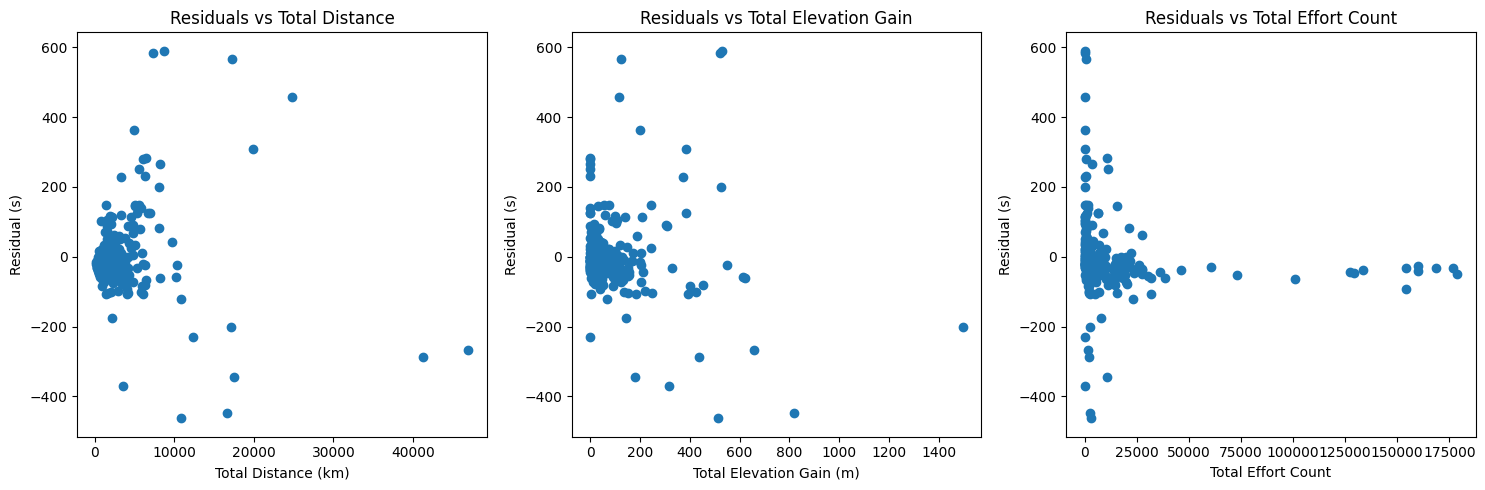

In [98]:
## undersand residual, which segments are poorly predicted
y_val_pred_1006 = pipeline1006.predict(X_val_ride_1006.select_dtypes(include=[np.number]))
residuals_1006 = y_val_ride_1006 - y_val_pred_1006
residuals_df_1006 = pd.DataFrame({
    'segment_id': X_val_ride_T1_MC.loc[y_val_ride_1006.index, 'segment_id'],
    'actual_time': y_val_ride_1006,
    'predicted_time': y_val_pred_1006,
    'residual': residuals_1006
})  
residuals_df_1006['abs_residual'] = residuals_df_1006['residual'].abs()
residuals_df_1006 = residuals_df_1006.sort_values(by='abs_residual', ascending=False)

##plot total_distance_km, total_elevation_gain, total_elevation_loss vs residuals
residuals_1006_merged = residuals_df_1006.merge(X_val_ride_T1_MC[['segment_id', 'distance', 'elevation_gain', 'total_effort_count']], on='segment_id', how='left')
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(residuals_1006_merged['distance'], residuals_1006_merged['residual'])
plt.xlabel('Total Distance (km)')
plt.ylabel('Residual (s)')
plt.title('Residuals vs Total Distance')
plt.subplot(1, 3, 2)
plt.scatter(residuals_1006_merged['elevation_gain'], residuals_1006_merged['residual'])
plt.xlabel('Total Elevation Gain (m)')
plt.ylabel('Residual (s)')
plt.title('Residuals vs Total Elevation Gain')
plt.subplot(1, 3, 3)
plt.scatter(residuals_1006_merged['total_effort_count'], residuals_1006_merged['residual'])
plt.xlabel('Total Effort Count')
plt.ylabel('Residual (s)')
plt.title('Residuals vs Total Effort Count')
plt.tight_layout()
plt.show()

### Model 1007 - Only physical scores - Routing

In [99]:
class ModelRouter3(BaseEstimator, RegressorMixin):
    def __init__(self, pipeline_1, pipeline_2, pipeline_3, 
                 threshold_1=1.0, threshold_2=2.0, 
                 segment_length_col='segment_length',
                 drop_routing_col=True):  # ← NOUVEAU paramètre
        self.pipeline_1 = pipeline_1
        self.pipeline_2 = pipeline_2
        self.pipeline_3 = pipeline_3
        self.threshold_1 = threshold_1
        self.threshold_2 = threshold_2
        self.segment_length_col = segment_length_col
        self.drop_routing_col = drop_routing_col  # ← NOUVEAU

    def _prepare_features(self, X):
        """Enlève la colonne de routing des features si demandé"""
        if self.drop_routing_col and self.segment_length_col in X.columns:
            return X.drop(columns=[self.segment_length_col])
        return X

    def fit(self, X, y):
        # Calculer les masques AVANT de retirer la colonne
        self.mask_1 = X[self.segment_length_col] <= self.threshold_1
        self.mask_2 = (X[self.segment_length_col] > self.threshold_1) & \
                      (X[self.segment_length_col] <= self.threshold_2)
        self.mask_3 = X[self.segment_length_col] > self.threshold_2

        # Préparer les features SANS la colonne de routing
        X_features = self._prepare_features(X)

        # Entraîner chaque pipeline sur son subset
        if np.any(self.mask_1):
            self.pipeline_1.fit(X_features[self.mask_1], y[self.mask_1])
        if np.any(self.mask_2):
            self.pipeline_2.fit(X_features[self.mask_2], y[self.mask_2])
        if np.any(self.mask_3):
            self.pipeline_3.fit(X_features[self.mask_3], y[self.mask_3])
        
        return self

    def predict(self, X):
        # Calculer les masques AVANT de retirer la colonne
        mask_1 = X[self.segment_length_col] <= self.threshold_1
        mask_2 = (X[self.segment_length_col] > self.threshold_1) & \
                 (X[self.segment_length_col] <= self.threshold_2)
        mask_3 = X[self.segment_length_col] > self.threshold_2

        # Préparer les features SANS la colonne de routing
        X_features = self._prepare_features(X)

        y_pred = np.zeros(len(X))
        if np.any(mask_1):
            y_pred[mask_1] = self.pipeline_1.predict(X_features[mask_1])
        if np.any(mask_2):
            y_pred[mask_2] = self.pipeline_2.predict(X_features[mask_2])
        if np.any(mask_3):
            y_pred[mask_3] = self.pipeline_3.predict(X_features[mask_3])
        
        return y_pred

In [100]:
feature_physics_score = ['physiological_score', 'time_score', 'energy_score', 'total_distance_km']
X_train_ride_1007 = X_train_ride_1000[feature_physics_score].copy()
y_train_ride_1007 = y_train_ride_1000.copy()
X_val_ride_1007 = X_val_ride_1000[feature_physics_score].copy()
y_val_ride_1007 = y_val_ride_1000.copy()

In [101]:
pipeline1007_short = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  

pipeline1007_medium = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])
pipeline1007_long = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  

model_router_1007 = ModelRouter3(pipeline1007_short, pipeline1007_medium, pipeline1007_long, threshold_1=1.0, threshold_2=10.0, segment_length_col='total_distance_km', drop_routing_col=True)
model_router_1007.fit(X_train_ride_1007, y_train_ride_1007)

,pipeline_1,Pipeline(step...dgeCV(cv=5))])
,pipeline_2,Pipeline(step...dgeCV(cv=5))])
,pipeline_3,Pipeline(step...dgeCV(cv=5))])
,threshold_1,1.0
,threshold_2,10.0
,segment_length_col,'total_distance_km'
,drop_routing_col,True
,copy,True
,with_mean,True
,with_std,True
,alphas,"(0.1, ...)"


In [102]:
plotting_pred_vs_actual_LC(model_router_1007, X_train_ride_1007, y_train_ride_1007, X_val_ride_1007, y_val_ride_1007, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120       12s     45     13s
  1-5min      365       34s    149     33s
 5-15min      205       85s     61     82s
15-60min       55      216s     20    275s
  >60min        7      236s      3    131s

GLOBAL - Train RMSE: 109.86
GLOBAL - Train MAE: 59.8s
GLOBAL - Validation RMSE: 103.69
GLOBAL - Validation MAE: 59.2s


c:\Users\coren\miniconda3\envs\tf\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning:


9 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\coren\miniconda3\envs\tf\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\coren\AppData\Local\Temp\ipykernel_35620\1077764031.py", line 36, in fit
  File "c:\Users\coren\miniconda3\envs\tf\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\coren\miniconda3\envs\tf\lib\site-pa

### Model 1008 - Feature selection + Routing 3 - RidgeCV

In [103]:
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select='auto', direction='forward')
sfs.fit(X_train_ride_1000.select_dtypes(include=[np.number]), y_train_ride_1000)
selected_features_1008 = X_train_ride_1000.select_dtypes(include=[np.number]).columns[sfs.get_support()]
if 'total_distance_km' not in selected_features_1008:
    selected_features_1008 = selected_features_1008.insert(0, 'total_distance_km')
print("Selected features:", selected_features_1008)

Selected features: Index(['total_distance_km', 'total_elevation_loss', 'max_grade',
       'grade_variance', 'early_climb_ratio', 'late_climb_ratio',
       'weighted_grade', 'first_third_avg_grade', 'middle_third_avg_grade',
       'cat_1_distance_km', 'cat_2_distance_km', 'uphill_distance_km',
       'flat_UH_interaction', 'UH_cat_3_interaction', 'UH_cat_2_interaction',
       'UH_cat_1_interaction', 'DH_cat_1_interaction', 'time_score',
       'energy_score'],
      dtype='object')


In [104]:
X_train_ride_1008 = X_train_ride_1000[selected_features_1008].copy()
y_train_ride_1008 = y_train_ride_1000.copy()
X_val_ride_1008 = X_val_ride_1000[selected_features_1008].copy()
y_val_ride_1008 = y_val_ride_1000.copy()

In [105]:
pipeline1008_short = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  

pipeline1008_medium = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])
pipeline1008_long = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  

model_router_1008 = ModelRouter3(pipeline1008_short, pipeline1008_medium, pipeline1008_long, threshold_1=1.0, threshold_2=10.0, segment_length_col='total_distance_km', drop_routing_col=True)
model_router_1008.fit(X_train_ride_1008, y_train_ride_1008)

,pipeline_1,Pipeline(step...dgeCV(cv=5))])
,pipeline_2,Pipeline(step...dgeCV(cv=5))])
,pipeline_3,Pipeline(step...dgeCV(cv=5))])
,threshold_1,1.0
,threshold_2,10.0
,segment_length_col,'total_distance_km'
,drop_routing_col,True
,copy,True
,with_mean,True
,with_std,True
,alphas,"(0.1, ...)"


In [106]:
plotting_pred_vs_actual_LC(model_router_1008, X_train_ride_1008, y_train_ride_1008, X_val_ride_1008, y_val_ride_1008, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120       11s     45     11s
  1-5min      365       31s    149     32s
 5-15min      205       70s     61     79s
15-60min       55      162s     20    306s
  >60min        7      184s      3     61s

GLOBAL - Train RMSE: 83.79
GLOBAL - Train MAE: 49.3s
GLOBAL - Validation RMSE: 115.85
GLOBAL - Validation MAE: 59.0s


c:\Users\coren\miniconda3\envs\tf\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning:


9 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\coren\miniconda3\envs\tf\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\coren\AppData\Local\Temp\ipykernel_35620\1077764031.py", line 36, in fit
  File "c:\Users\coren\miniconda3\envs\tf\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\coren\miniconda3\envs\tf\lib\site-pa

### Model 1009 - Only physical scores - Routing 4 - RidgeCV

In [107]:
class ModelRouter4(BaseEstimator, RegressorMixin):
    def __init__(self, pipeline_1, pipeline_2, pipeline_3, pipeline_4,
                 threshold_1=1.0, threshold_2=2.0, threshold_3=5.0, 
                 segment_length_col='segment_length',
                 drop_routing_col=True):  # ← NOUVEAU paramètre
        self.pipeline_1 = pipeline_1
        self.pipeline_2 = pipeline_2
        self.pipeline_3 = pipeline_3
        self.pipeline_4 = pipeline_4
        self.threshold_1 = threshold_1
        self.threshold_2 = threshold_2
        self.threshold_3 = threshold_3
        self.segment_length_col = segment_length_col
        self.drop_routing_col = drop_routing_col  # ← NOUVEAU

    def _prepare_features(self, X):
        """Enlève la colonne de routing des features si demandé"""
        if self.drop_routing_col and self.segment_length_col in X.columns:
            return X.drop(columns=[self.segment_length_col])
        return X

    def fit(self, X, y):
        # Calculer les masques AVANT de retirer la colonne
        self.mask_1 = X[self.segment_length_col] <= self.threshold_1
        self.mask_2 = (X[self.segment_length_col] > self.threshold_1) & \
                      (X[self.segment_length_col] <= self.threshold_2)
        self.mask_3 = (X[self.segment_length_col] > self.threshold_2) & \
                      (X[self.segment_length_col] <= self.threshold_3)
        self.mask_4 = X[self.segment_length_col] > self.threshold_3

        # Préparer les features SANS la colonne de routing
        X_features = self._prepare_features(X)

        # Entraîner chaque pipeline sur son subset
        if np.any(self.mask_1):
            self.pipeline_1.fit(X_features[self.mask_1], y[self.mask_1])
        if np.any(self.mask_2):
            self.pipeline_2.fit(X_features[self.mask_2], y[self.mask_2])
        if np.any(self.mask_3):
            self.pipeline_3.fit(X_features[self.mask_3], y[self.mask_3])
        if np.any(self.mask_4):
            self.pipeline_4.fit(X_features[self.mask_4], y[self.mask_4])
        
        return self

    def predict(self, X):
        # Calculer les masques AVANT de retirer la colonne
        mask_1 = X[self.segment_length_col] <= self.threshold_1
        mask_2 = (X[self.segment_length_col] > self.threshold_1) & \
                 (X[self.segment_length_col] <= self.threshold_2)
        mask_3 = (X[self.segment_length_col] > self.threshold_2) & \
                 (X[self.segment_length_col] <= self.threshold_3)
        mask_4 = X[self.segment_length_col] > self.threshold_3

        # Préparer les features SANS la colonne de routing
        X_features = self._prepare_features(X)

        y_pred = np.zeros(len(X))
        if np.any(mask_1):
            y_pred[mask_1] = self.pipeline_1.predict(X_features[mask_1])
        if np.any(mask_2):
            y_pred[mask_2] = self.pipeline_2.predict(X_features[mask_2])
        if np.any(mask_3):
            y_pred[mask_3] = self.pipeline_3.predict(X_features[mask_3])
        if np.any(mask_4):
            y_pred[mask_4] = self.pipeline_4.predict(X_features[mask_4])
        
        return y_pred

In [108]:
feature_physics_score = ['physiological_score', 'time_score', 'energy_score', 'total_distance_km']
X_train_ride_1009 = X_train_ride_1000[feature_physics_score].copy()
y_train_ride_1009 = y_train_ride_1000.copy()
X_val_ride_1009 = X_val_ride_1000[feature_physics_score].copy()
y_val_ride_1009 = y_val_ride_1000.copy()

In [109]:
pipeline1009_1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  

pipeline1009_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])
pipeline1009_3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  
pipeline1009_4 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  

model_router_1009 = ModelRouter4(pipeline1009_1, pipeline1009_2, pipeline1009_3, pipeline1009_4, threshold_1=1.0, threshold_2=2.0,threshold_3=4.0, segment_length_col='total_distance_km', drop_routing_col=True)
model_router_1009.fit(X_train_ride_1008, y_train_ride_1008)

,pipeline_1,Pipeline(step...dgeCV(cv=5))])
,pipeline_2,Pipeline(step...dgeCV(cv=5))])
,pipeline_3,Pipeline(step...dgeCV(cv=5))])
,pipeline_4,Pipeline(step...dgeCV(cv=5))])
,threshold_1,1.0
,threshold_2,2.0
,threshold_3,4.0
,segment_length_col,'total_distance_km'
,drop_routing_col,True
,copy,True
,with_mean,True


In [110]:
plotting_pred_vs_actual_LC(model_router_1009, X_train_ride_1009, y_train_ride_1008, X_val_ride_1009, y_val_ride_1009, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120       12s     45     13s
  1-5min      365       32s    149     33s
 5-15min      205       79s     61     78s
15-60min       55      212s     20    270s
  >60min        7      219s      3    156s

GLOBAL - Train RMSE: 107.25
GLOBAL - Train MAE: 56.3s
GLOBAL - Validation RMSE: 105.31
GLOBAL - Validation MAE: 58.1s


### Model 1010 - Routing 4 - LassoCV

In [111]:
X_train_ride_1010 = X_train_ride_1000.copy()
y_train_ride_1010 = y_train_ride_1000.copy()
X_val_ride_1010 = X_val_ride_1000.copy()
y_val_ride_1010 = y_val_ride_1000.copy()

In [112]:
pipeline1010_1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(cv=10, max_iter=10000))
    ])  

pipeline1010_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(cv=10, max_iter=10000))
    ])
pipeline1010_3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(cv=10, max_iter=10000))
    ])  
pipeline1010_4 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LassoCV(cv=10, max_iter=10000))
    ])  

model_router_1010 = ModelRouter4(pipeline1010_1, pipeline1010_2, pipeline1010_3, pipeline1010_4, threshold_1=1.0, threshold_2=2.0,threshold_3=4.0, segment_length_col='total_distance_km', drop_routing_col=True)
model_router_1010.fit(X_train_ride_1010, y_train_ride_1010)

,pipeline_1,Pipeline(step...iter=10000))])
,pipeline_2,Pipeline(step...iter=10000))])
,pipeline_3,Pipeline(step...iter=10000))])
,pipeline_4,Pipeline(step...iter=10000))])
,threshold_1,1.0
,threshold_2,2.0
,threshold_3,4.0
,segment_length_col,'total_distance_km'
,drop_routing_col,True
,copy,True
,with_mean,True


In [113]:
plotting_pred_vs_actual_LC(model_router_1010, X_train_ride_1010, y_train_ride_1010, X_val_ride_1010, y_val_ride_1010, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120       11s     45     13s
  1-5min      365       28s    149     36s
 5-15min      205       67s     61     80s
15-60min       55      183s     20    272s
  >60min        7      199s      3    193s

GLOBAL - Train RMSE: 87.83
GLOBAL - Train MAE: 48.7s
GLOBAL - Validation RMSE: 104.91
GLOBAL - Validation MAE: 60.5s


c:\Users\coren\miniconda3\envs\tf\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning:


4 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\coren\miniconda3\envs\tf\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\coren\AppData\Local\Temp\ipykernel_35620\2657000260.py", line 40, in fit
  File "c:\Users\coren\miniconda3\envs\tf\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\coren\miniconda3\envs\tf\lib\site-pa

### Model 1011 - Feature selection + Routing 4 - RidgeCV

In [122]:
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select='auto', direction='forward')
sfs.fit(X_train_ride_1000.select_dtypes(include=[np.number]), y_train_ride_1000)
selected_features_1011 = X_train_ride_1000.select_dtypes(include=[np.number]).columns[sfs.get_support()]
if 'total_distance_km' not in selected_features_1011:
    selected_features_1011 = selected_features_1011.insert(0, 'total_distance_km')
print("Selected features:", selected_features_1011)

Selected features: Index(['total_distance_km', 'total_elevation_loss', 'max_grade',
       'grade_variance', 'early_climb_ratio', 'late_climb_ratio',
       'weighted_grade', 'first_third_avg_grade', 'middle_third_avg_grade',
       'cat_1_distance_km', 'cat_2_distance_km', 'uphill_distance_km',
       'flat_UH_interaction', 'UH_cat_3_interaction', 'UH_cat_2_interaction',
       'UH_cat_1_interaction', 'DH_cat_1_interaction', 'time_score',
       'energy_score'],
      dtype='object')


In [123]:
X_train_ride_1011 = X_train_ride_1000[selected_features_1011].copy()
y_train_ride_1011 = y_train_ride_1000.copy()
X_val_ride_1011 = X_val_ride_1000[selected_features_1011].copy()
y_val_ride_1011 = y_val_ride_1000.copy()

In [124]:
pipeline1011_1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  

pipeline1011_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])
pipeline1011_3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  
pipeline1011_4 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5))
    ])  

model_router_1011 = ModelRouter4(pipeline1011_1, pipeline1011_2, pipeline1011_3, pipeline1011_4, threshold_1=1.0, threshold_2=2.0,threshold_3=4.0, segment_length_col='total_distance_km', drop_routing_col=True)
model_router_1011.fit(X_train_ride_1011, y_train_ride_1011)

,pipeline_1,Pipeline(step...dgeCV(cv=5))])
,pipeline_2,Pipeline(step...dgeCV(cv=5))])
,pipeline_3,Pipeline(step...dgeCV(cv=5))])
,pipeline_4,Pipeline(step...dgeCV(cv=5))])
,threshold_1,1.0
,threshold_2,2.0
,threshold_3,4.0
,segment_length_col,'total_distance_km'
,drop_routing_col,True
,copy,True
,with_mean,True


In [125]:
plotting_pred_vs_actual_LC(model_router_1011, X_train_ride_1011, y_train_ride_1011, X_val_ride_1011, y_val_ride_1011, X_train_ride_T1_MC, X_val_ride_T1_MC)


PERFORMANCE PAR BIN DE DURÉE
   Durée  Train N Train MAE  Val N Val MAE
   <1min      120       11s     45     11s
  1-5min      365       28s    149     34s
 5-15min      205       69s     61     82s
15-60min       55      185s     20    265s
  >60min        7      191s      3    201s

GLOBAL - Train RMSE: 87.46
GLOBAL - Train MAE: 49.6s
GLOBAL - Validation RMSE: 103.36
GLOBAL - Validation MAE: 59.1s


# Final Test

In [126]:
pipeline_dict = {
    'Baseline Model (Basic Features) #0': [pipeline_bm, X_train_ride_T1_bm, y_train_ride_T1_bm, X_val_ride_T1_bm, y_val_ride_T1_bm, X_train_ride_T1, X_val_ride_T1],
    'Ridge Regression (Advanced Features) #1': [pipeline1, X_train_ride_1, y_train_ride_1, X_val_ride_1, y_val_ride_1, X_train_ride_T1, X_val_ride_T1],
    'ElasticNet Regression (Advanced Features) #2': [pipeline2, X_train_ride_2, y_train_ride_2, X_val_ride_2, y_val_ride_2, X_train_ride_T1, X_val_ride_T1],
    'RidgeCV Regression (Advanced Features) #3': [pipeline3, X_train_ride_3, y_train_ride_3, X_val_ride_3, y_val_ride_3, X_train_ride_T1, X_val_ride_T1],
    'LassoCV Regression (Advanced Features) #4': [pipeline4, X_train_ride_4, y_train_ride_4, X_val_ride_4, y_val_ride_4, X_train_ride_T1, X_val_ride_T1],
    'LassoCV Regression (More Advanced Features) #10': [pipeline10, X_train_ride_10, y_train_ride_10, X_val_ride_10, y_val_ride_10, X_train_ride_T1, X_val_ride_T1],
    'SGDRegressor (More Advanced Features) #11': [pipeline11, X_train_ride_11, y_train_ride_11, X_val_ride_11, y_val_ride_11, X_train_ride_T1, X_val_ride_T1],
    'LassoLarsCV (More Advanced Features) #12': [pipeline12, X_train_ride_12, y_train_ride_12, X_val_ride_12, y_val_ride_12, X_train_ride_T1, X_val_ride_T1],
    'Baseline Model (Basic Features / Medium Confidence) #0': [pipeline_MC_bm, X_train_ride_T1_MC_bm, y_train_ride_T1_MC_bm, X_val_ride_T1_MC_bm, y_val_ride_T1_MC_bm, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'RidgeCV Regression (Advanced Features / Medium Confidence) #100': [pipeline100, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'RandomForestRegressor (Advanced Features / Medium Confidence) #101': [pipeline101, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'AdaBoostRegressor (Advanced Features / Medium Confidence) #102': [pipeline102, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'LassoCV Regression (Advanced Features / Medium Confidence) #103': [pipeline103, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'GradientBoostingRegressor (Advanced Features / Medium Confidence) #104': [pipeline104, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'StackingRegressor (Advanced Features / Medium Confidence) #105': [pipeline105, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'ModelRouter2 RidgeCV (Advanced Features / Medium Confidence) #106': [model_router_106, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'ModelRouter2 LassoCV (Advanced Features / Medium Confidence) #107': [model_router_107, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'LinearRegression (Advanced Features / Medium Confidence) #108': [pipeline108, X_train_ride_100, y_train_ride_100, X_val_ride_100, y_val_ride_100, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'RidgeCV Regression (More Advanced Features / Medium Confidence) #1001': [pipeline1001, X_train_ride_1000, y_train_ride_1000, X_val_ride_1000, y_val_ride_1000, X_train_ride_T1_MC, X_val_ride_T1_MC],
    #'RandomForestRegressor (More Advanced Features / Medium Confidence) #1002': [pipeline1002, X_train_ride_1000, y_train_ride_1000, X_val_ride_1000, y_val_ride_1000, X_train_ride_T1_MC, X_val_ride_T1_MC],
    #'AdaBoostRegressor (More Advanced Features / Medium Confidence) #1003': [pipeline1003, X_train_ride_1000, y_train_ride_1000, X_val_ride_1000, y_val_ride_1000, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'LinearRegression (Selected Features / Medium Confidence) #1004': [pipeline1004, X_train_ride_1004, y_train_ride_1004, X_val_ride_1004, y_val_ride_1004, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'RidgeCV Regression (Selected Features / Medium Confidence) #1005': [pipeline1005, X_train_ride_1005, y_train_ride_1005, X_val_ride_1005, y_val_ride_1005, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'LinearRegression (Physics Score Features / Medium Confidence) #1006': [pipeline1006, X_train_ride_1006, y_train_ride_1006, X_val_ride_1006, y_val_ride_1006, X_train_ride_T1_MC, X_val_ride_T1_MC],
    'ModelRouter3 RidgeCV (Physics Score Features / Medium Confidence) #1007': [model_router_1007, X_train_ride_1007, y_train_ride_1007, X_val_ride_1007, y_val_ride_1007, X_train_ride_T1_MC, X_val_ride_1007],
    'ModelRouter3 RidgeCV (Selected Features / Medium Confidence) #1008': [model_router_1008, X_train_ride_1008, y_train_ride_1008, X_val_ride_1008, y_val_ride_1008, X_train_ride_T1_MC, X_val_ride_1008], 
    'ModelRouter4 RidgeCV (Physics Score Features / Medium Confidence) #1009': [model_router_1009, X_train_ride_1009, y_train_ride_1009, X_val_ride_1009, y_val_ride_1009, X_train_ride_T1_MC, X_val_ride_1009],
    'ModelRouter4 LassoCV (All Features / Medium Confidence) #1010': [model_router_1010, X_train_ride_1010, y_train_ride_1010, X_val_ride_1010, y_val_ride_1010, X_train_ride_T1_MC, X_val_ride_1010],
    'ModelRouter4 RidgeCV (Selected Features / Medium Confidence) #1011': [model_router_1011, X_train_ride_1011, y_train_ride_1011, X_val_ride_1011, y_val_ride_1011, X_train_ride_T1_MC, X_val_ride_1011]
}

In [127]:
# Définir les bins
bins = [0, 60, 300, 900, 3600, np.inf]
bin_labels = ['<1min', '1-5min', '5-15min', '15-60min', '>60min']
bin_upper_bounds = [60, 300, 900, 3600, 3600]  # Borne supérieure pour chaque bin (dernière = 1h)

# Dictionnaire pour stocker les résultats
results_by_model = {}

# Calculer MAE par bin pour chaque modèle
for model_name, components in pipeline_dict.items():
    pipeline, X_train, y_train, X_val, y_val = components[0:5]
    
    # Prédictions
    y_val_pred = pipeline.predict(X_val.select_dtypes(include=[np.number]))
    
    # Créer bins
    val_df = pd.DataFrame({'actual': y_val, 'pred': y_val_pred})
    val_df['bin'] = pd.cut(val_df['actual'], bins=bins, labels=bin_labels)
    
    # Calculer MAE par bin
    val_mae_by_bin = []
    
    for bin_label in bin_labels:
        val_mask = val_df['bin'] == bin_label
        
        if val_mask.sum() > 0:
            val_mae = mean_absolute_error(
                val_df.loc[val_mask, 'actual'],
                val_df.loc[val_mask, 'pred']
            )
            val_mae_by_bin.append(val_mae)
        else:
            val_mae_by_bin.append(np.nan)
    
    # Raccourcir le nom du modèle
    results_by_model[model_name] = val_mae_by_bin

# Créer matrice MAE absolue
mae_matrix = np.array([data for data in results_by_model.values()])

# Calculer le % relatif à la borne supérieure de chaque bin
relative_matrix = np.zeros_like(mae_matrix)

for i in range(mae_matrix.shape[0]):  # Pour chaque modèle
    for j in range(mae_matrix.shape[1]):  # Pour chaque bin
        if not np.isnan(mae_matrix[i, j]):
            relative_matrix[i, j] = (mae_matrix[i, j] / bin_upper_bounds[j]) * 100
        else:
            relative_matrix[i, j] = np.nan

# Créer annotations avec MAE absolue et % relatif
annotations = []
for i in range(mae_matrix.shape[0]):
    for j in range(mae_matrix.shape[1]):
        if not np.isnan(mae_matrix[i, j]):
            text = f"{mae_matrix[i, j]:.0f}s<br>{relative_matrix[i, j]:.0f}%"
        else:
            text = "N/A"
        annotations.append(text)

annotations_matrix = np.array(annotations).reshape(mae_matrix.shape)

# Créer la heatmap
fig = go.Figure(data=go.Heatmap(
    z=relative_matrix,
    x=bin_labels,
    y=list(results_by_model.keys()),
    colorscale='RdYlGn_r',  # Rouge = pire, Vert = meilleur
    text=annotations_matrix,
    texttemplate='%{text}',
    textfont={"size": 10},
    colorbar=dict(
        title="MAE vs Borne<br>Supérieure (%)",
        ticksuffix="%",
        tickformat=".1f"
    ),
    zmax=20,  # 20% de la borne supérieure
    zmin=0
))

fig.update_layout(
    title={
        'text': "📊 Performance Relative par Bin - MAE en % de la Borne Supérieure",
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    xaxis_title="Bins de Temps",
    yaxis_title="Modèles",
    height=max(400, len(results_by_model) * 40),  # Hauteur dynamique
    width=900,
    margin=dict(l=400),
    xaxis={'side': 'bottom'},
    yaxis={'autorange': 'reversed'}  # Meilleurs modèles en haut
)

fig.show()

# Identifier le meilleur modèle par bin
print("\n🏆 MEILLEURS MODÈLES PAR BIN:")
print("-" * 130)
for j, bin_label in enumerate(bin_labels):
    best_idx = np.nanargmin(mae_matrix[:, j])
    best_model = list(results_by_model.keys())[best_idx]
    best_mae = mae_matrix[best_idx, j]
    best_pct = relative_matrix[best_idx, j]
    if not np.isnan(best_mae):
        print(f"{bin_label:>10} : {best_model:<45} (MAE = {best_mae:.1f}s = {best_pct:.1f}% de {bin_upper_bounds[j]}s)")


🏆 MEILLEURS MODÈLES PAR BIN:
----------------------------------------------------------------------------------------------------------------------------------
     <1min : ModelRouter3 RidgeCV (Selected Features / Medium Confidence) #1008 (MAE = 10.8s = 17.9% de 60s)
    1-5min : RidgeCV Regression (More Advanced Features / Medium Confidence) #1001 (MAE = 31.7s = 10.6% de 300s)
   5-15min : LassoCV Regression (Advanced Features) #4     (MAE = 68.5s = 7.6% de 900s)
  15-60min : RidgeCV Regression (More Advanced Features / Medium Confidence) #1001 (MAE = 228.1s = 6.3% de 3600s)
    >60min : ModelRouter2 LassoCV (Advanced Features / Medium Confidence) #107 (MAE = 46.0s = 1.3% de 3600s)


In [134]:
# plot results of the choosen model on the test set
choosen_model = model_router_1011


X_test_ride_1011 = X_test_ride_1000[selected_features_1011].copy()
y_test_ride_1011 = y_test_ride_1000.copy()

# Evaluate choosen model on test set, MAE by bins
y_test_pred_1011 = choosen_model.predict(X_test_ride_1011)

In [137]:
def plotting_MAE_bins2(y_train, y_train_pred, y_val, y_val_pred, y_test, y_test_pred):
    # Définir les bins de durée
    bins = [0, 60, 300, 900, 3600, np.inf]
    labels = ['<1min', '1-5min', '5-15min', '15-60min', '>60min']

    # Créer DataFrames temporaires avec bins
    train_df = pd.DataFrame({
        'actual': y_train,
        'pred': y_train_pred
    })
    train_df['bin'] = pd.cut(train_df['actual'], bins=bins, labels=labels)

    val_df = pd.DataFrame({
        'actual': y_val,
        'pred': y_val_pred
    })
    val_df['bin'] = pd.cut(val_df['actual'], bins=bins, labels=labels)

    test_df = pd.DataFrame({
        'actual': y_test,
        'pred': y_test_pred
    })
    test_df['bin'] = pd.cut(test_df['actual'], bins=bins, labels=labels)

    # Calculer les métriques par bin
    results = []
    for bin_label in labels:
        train_mask = train_df['bin'] == bin_label
        val_mask = val_df['bin'] == bin_label
        test_mask = test_df['bin'] == bin_label
        
        if train_mask.sum() > 0 and val_mask.sum() > 0 and test_mask.sum() > 0:
            train_mae = np.mean(np.abs(train_df.loc[train_mask, 'actual'] - train_df.loc[train_mask, 'pred']))
            val_mae = np.mean(np.abs(val_df.loc[val_mask, 'actual'] - val_df.loc[val_mask, 'pred']))
            test_mae = np.mean(np.abs(test_df.loc[test_mask, 'actual'] - test_df.loc[test_mask, 'pred']))
            
            train_n = train_mask.sum()
            val_n = val_mask.sum()
            test_n = test_mask.sum()

            results.append({
                'Durée': bin_label,
                'Train N': train_n,
                'Train MAE': f"{train_mae:.0f}s",
                'Val N': val_n,
                'Val MAE': f"{val_mae:.0f}s",
                'Test N': test_n,
                'Test MAE': f"{test_mae:.0f}s"
            })

    # Créer et afficher le tableau
    results_df = pd.DataFrame(results)
    print("\n📊 Performance par Bin - MAE Absolue")
    print(results_df)

In [138]:
plotting_MAE_bins2(y_train_ride_1011, choosen_model.predict(X_train_ride_1011), y_val_ride_1011, choosen_model.predict(X_val_ride_1011), y_test_ride_1011, y_test_pred_1011)


📊 Performance par Bin - MAE Absolue
      Durée  Train N Train MAE  Val N Val MAE  Test N Test MAE
0     <1min      120       11s     45     11s      18     376s
1    1-5min      365       28s    149     34s      48     250s
2   5-15min      205       69s     61     82s      36     331s
3  15-60min       55      185s     20    265s      10    1137s
4    >60min        7      191s      3    201s       2    5996s
